# 02. Data Pre-Processing — GSE69914

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║   POLITECNICO DI TORINO — MSc Mathematical Engineering           ║
# ║   THESIS: Advanced Study of Epigenetic Mechanisms in Neoplasms   ║
# ╟──────────────────────────────────────────────────────────────────╢
# ║ Author:       Elisabetta Roviera (s328422)                       ║
# ║ Supervisors:  Dr. Sandro Gambino, Prof. Alfredo Benso            ║
# ╟──────────────────────────────────────────────────────────────────╢
# ║ Notebook:     02-data-pre-processing-GSE69914                    ║
# ║ Description:  MANCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA          ║
# ║ Dataset(s):   GSE69914                                           ║
# ║ Repository:   github.com/elisabettaroviera/THESIS                ║
# ╟──────────────────────────────────────────────────────────────────╢
# ║ Date: 28-Nov-2025 | Python 3.11.13                               ║
# ╚══════════════════════════════════════════════════════════════════╝


### Libraries

In [2]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [4]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

## STEP 0 — Initial Pre-processing

### CELL 0.1 — Load β-matrix and phenotype table

In [5]:
# LOAD BETA AND PHENOTYPE TABLES
# Load beta-value matrix (Parquet) and phenotype table, check alignment and basic issues.
BETA_PATH = "" # ADD PATH
PHENO_PATH = ""    # ADD PATH

BETA_PATH = "/kaggle/input/gse69914-parquet/GSE69914.parquet"     
PHENO_PATH = "/kaggle/input/pheno-gse69914/pheno_GSE69914.parquet"    

# Read Parquet files
beta_pl = pl.read_parquet(BETA_PATH)              # Load beta matrix
pheno_pl = pl.read_parquet(PHENO_PATH)            # Load phenotype metadata

print(f"beta_pl.shape: {beta_pl.shape}")
print(f"pheno_pl.shape: {pheno_pl.shape}")


beta_pl.shape: (407, 485514)
pheno_pl.shape: (407, 10)


### CELL 0.2 — Basic sanity checks

In [6]:
# BASIC CHECKS ON PHENOTYPE TABLE
# Verify unique sample IDs, missing values, and expected fields.
# Check for duplicated id_tissue in phenotype
dup_ids = pheno_pl["id_tissue"].is_duplicated().any()
if dup_ids:
    raise ValueError("Duplicated sample IDs found in phenotype table.")

# Check required fields
required_cols = ["id_tissue", "label"]
missing_cols = [c for c in required_cols if c not in pheno_pl.columns]
if missing_cols:
    raise KeyError(f"Missing required phenotype columns: {missing_cols}")

pheno_pl.head()


id_tissue,label,sentrix_id,slide_id,er,pr,her2,ki67,group,batch
str,i64,str,str,i64,i64,i64,i64,str,str
"""GSM1712367""",2,"""9257626003_r01c01""","""9257626003""",1,1,0,1,"""Tumor""","""9257626003"""
"""GSM1712368""",1,"""9257626003_r01c02""","""9257626003""",null,null,null,null,"""Adjacent""","""9257626003"""
"""GSM1712369""",0,"""9257626003_r02c01""","""9257626003""",null,null,null,null,"""Normal""","""9257626003"""
"""GSM1712370""",2,"""9257626003_r02c02""","""9257626003""",1,1,0,null,"""Tumor""","""9257626003"""
"""GSM1712371""",2,"""9257626003_r03c01""","""9257626003""",1,1,0,0,"""Tumor""","""9257626003"""


### CELL 0.3 — Harmonize phenotype with β-matrix

In [7]:
# ALIGN PHENOTYPE AND BETA MATRIX
# Keep only samples present in both tables to ensure consistent joint analysis.

# Extract sample IDs from beta matrix
beta_ids = beta_pl["id_tissue"].to_list()
pheno_ids = pheno_pl["id_tissue"].to_list()

# Intersect sample IDs
shared = set(beta_ids).intersection(pheno_ids)
print("Shared samples:", len(shared))

# Filter both tables
beta_pl = beta_pl.filter(pl.col("id_tissue").is_in(shared))
pheno_pl = pheno_pl.filter(pl.col("id_tissue").is_in(shared))


Shared samples: 407


### CELL 0.4 — Check Missingness

In [8]:
# CHECK MISSINGNESS (QUICK DIAGNOSTIC)
# Verify if any missing values are present—datasets should be complete.

cpg_cols = [c for c in beta_pl.columns if c not in ["id_tissue", "label"]]

# Count missing values per CpG (column-wise)
n_missing_cpgs = (
    beta_pl.select([pl.col(c).is_null().sum().alias(c) for c in cpg_cols])
    .to_pandas()
    .sum()
    .sum()
)

# Count missing values per sample (row-wise)
n_missing_samples = (
    beta_pl
    .select(pl.sum_horizontal(pl.all().exclude(["id_tissue", "label"]).is_null()).alias("na_per_sample"))
    ["na_per_sample"]
    .sum()
)

# Print diagnostic summary
if n_missing_cpgs == 0 and n_missing_samples == 0:
    print("✓ No missing values detected — dataset is complete.")
else:
    print(f"Missing CpG entries: {int(n_missing_cpgs)}")
    print(f"Missing sample entries: {int(n_missing_samples)}")


✓ No missing values detected — dataset is complete.


### CELL 0.5 — Type I / Type II probe distribution diagnostic (no BMIQ yet)

Collected CpGs → Type I: 121,961   Type II: 327,560


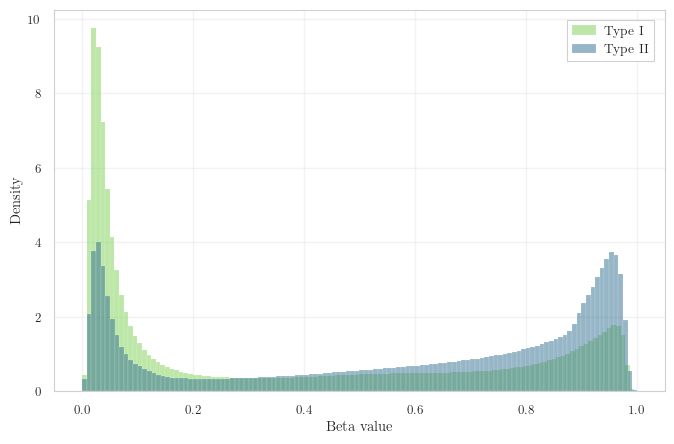

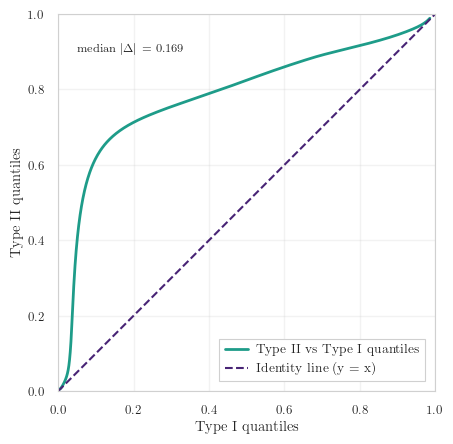

Median absolute deviation from identity (Q–Q): 0.1692 (lower ≈ better alignment)


In [9]:
# TYPE-I / TYPE-II BIAS DIAGNOSTIC 
# Uses ALL CpGs (Type I & Type II) present in your Polars matrix
PROBE_MAP_CSV = "/kaggle/input/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"  

# Load matrix (as LazyFrame) 
LF = beta_pl.lazy() if isinstance(beta_pl, pl.DataFrame) else beta_pl
schema_cols = list(LF.schema.keys())

# Detect CpG columns (wide format: Samples x CpGs, CpGs = columns)
cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
if not cpg_cols:
    raise ValueError("No CpG-like columns found (expected columns starting with 'cg' or 'ch').")

# READ EPIC MANIFEST AND MAP CPG TO INFNIUM DESIGN TYPE
# We parse the CSV manually and keep only IlmnID and Infinium_Design_Type
import csv

rows = []
with open(PROBE_MAP_CSV, newline="") as f:
    reader = csv.reader(f)
    # Skip Illumina metadata and reach the header row
    for _ in range(7):
        next(reader, None)
    header = next(reader)

    # Find column indices for IlmnID and Infinium_Design_Type
    try:
        idx_ilmn = header.index("IlmnID")
        idx_type = header.index("Infinium_Design_Type")
    except ValueError as e:
        raise RuntimeError(f"Could not find IlmnID / Infinium_Design_Type in manifest header: {header}") from e

    # Iterate over remaining lines and collect only cg probes with valid type
    for row in reader:
        if len(row) <= max(idx_ilmn, idx_type):
            continue
        ilmn = row[idx_ilmn].strip()
        t    = row[idx_type].strip()
        if not ilmn.startswith("cg"):
            continue
        if t not in ("I", "II"):
            continue
        rows.append((ilmn, t))

probe_map = pl.DataFrame(rows, schema=["CpG", "Type"])

# Intersect with CpGs present in the matrix
typeI_cpgs  = set(probe_map.filter(pl.col("Type") == "I")["CpG"].to_list())  & set(cpg_cols)
typeII_cpgs = set(probe_map.filter(pl.col("Type") == "II")["CpG"].to_list()) & set(cpg_cols)

if not typeI_cpgs or not typeII_cpgs:
    raise ValueError("Type I or Type II CpG sets are empty after intersecting with your matrix columns.")

# Collect all values per Type (no subsampling)
def collect_values_for(cpg_set: Iterable[str]) -> np.ndarray:
    cols = sorted(list(cpg_set))
    # Collect as 2D (Samples x CpGs) then flatten; keep finite values in [0,1]
    M = LF.select(cols).collect(streaming=True).to_numpy()
    vec = M.ravel()
    vec = vec[np.isfinite(vec)]
    return vec[(vec >= 0.0) & (vec <= 1.0)]

vals_I  = collect_values_for(typeI_cpgs)
vals_II = collect_values_for(typeII_cpgs)

print(f"Collected CpGs → Type I: {len(typeI_cpgs):,}   Type II: {len(typeII_cpgs):,}")

# Build figure 
apply_thesis_style(use_tex=True)
cmap = plt.cm.get_cmap("viridis")

# Overlaid density via normalized histograms
plt.figure()
plt.hist(
    vals_I,
    bins=120,
    density=True,
    alpha=0.50,
    label="Type I",
    color=cmap(0.80),
    edgecolor="white",
    linewidth=0.2,
)
plt.hist(
    vals_II,
    bins=120,
    density=True,
    alpha=0.50,
    label="Type II",
    color=cmap(0.35),
    edgecolor="white",
    linewidth=0.2,
)
plt.xlabel("Beta value")
plt.ylabel("Density")
place_legend(position="upper right")
plt.tight_layout()
plt.savefig("type_bias_density.pdf", bbox_inches="tight")
plt.show()

# Q–Q plot (Type II quantiles vs Type I)
q   = np.linspace(0.001, 0.999, 500)
qI  = np.quantile(vals_I,  q)
qII = np.quantile(vals_II, q)
mad = float(np.median(np.abs(qII - qI)))  # alignment metric

plt.figure()
plt.plot(qI, qII, lw=2, color=cmap(0.55), label="Type II vs Type I quantiles")
plt.plot([0, 1], [0, 1], ls="--", color=cmap(0.10), label="Identity line (y = x)")
plt.xlabel("Type I quantiles")
plt.ylabel("Type II quantiles")
ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.text(0.05, 0.90, f"median $|\\Delta|$ = {mad:.3f}", transform=ax.transAxes)
place_legend(ax, "lower right")
plt.tight_layout()
plt.savefig("type_bias_qqplot.pdf", bbox_inches="tight")
plt.show()

print(f"Median absolute deviation from identity (Q–Q): {mad:.4f} (lower ≈ better alignment)")


## STEP 1 — Technical filtering

### CELL 1.1 — Technical filtering imports and paths

In [10]:
# TECHNICAL FILTERING IMPORTS AND PATHS
# Import required modules and define paths to external technical probe lists.

# Paths to external technical probe lists (update paths if needed)
NAEEM_CSV        = "/kaggle/input/filtering-cpg-naeem/filtering_table.csv"                       # Naeem 2014
PIDSLEY_CSV      = "/kaggle/input/filtering-cpg-pidsley/Chen2013_full_blacklist.csv"             # Pidsley 2016
CHEN_CROSS_CSV   = "/kaggle/input/filtering-cpg-chen-cross-reactive/chen_2013_cross_reactive.csv"  # Chen 2013
ZHOU_TSV         = "/kaggle/input/filtering-cpg-zhou/EPIC.anno.GRCh38.tsv"                       # Zhou 2016
MCCARTNEY_CROSS_CPG   = "/kaggle/input/filtering-cpg-mccartney-2/1-s2.0-S221359601630071X-mmc2.txt"   # McCartney 2016 file 2 (CpG cross-hyb)
MCCARTNEY_CROSS_NONCG = "/kaggle/input/filtering-cpg-mccartney-3/1-s2.0-S221359601630071X-mmc3.txt"   # McCartney 2016 file 3 (non-CpG cross-hyb)


### CELL 1.2 — Helper and Inspection analysis

In [11]:
# HELPER FUNCTIONS FOR TECHNICAL PROBE LISTS
# Define robust loaders for Naeem, Pidsley, Chen, Zhou, McCartney lists.

def load_naeem_drop_set(
    path: str,
    probe_cands: Iterable[str] = ("probe", "IlmnID", "ID_REF", "cg", "Name"),
    flag_cands: Iterable[str] = ("Flag(discard/keep)", "flag(discard/keep)", "flag", "flag_discard_keep"),
) -> Set[str]:
    """Return probes flagged as 'discard' in Naeem table."""
    df = pl.read_csv(path)
    probe_col = next((c for c in probe_cands if c in df.columns), None)
    flag_col = next((c for c in df.columns if str(c).lower().strip().startswith("flag")), None) \
               or next((c for c in flag_cands if c in df.columns), None)
    assert probe_col and flag_col, f"Naeem file columns not found. Seen: {df.columns}"

    probes = df[probe_col].cast(pl.Utf8).str.strip_chars()
    flags = df[flag_col].cast(pl.Utf8).str.to_lowercase()

    return set(probes.filter(flags.str.contains("discard")).to_list())


def load_pidsley_drop_set(path: str, skip_first_lines: int = 1) -> Set[str]:
    """Robust loader for Pidsley full blacklist."""
    df_comma = pl.read_csv(
        path,
        has_header=True,
        infer_schema_length=10000,
        separator=",",
        skip_rows=skip_first_lines,
    )
    try:
        df_tab = pl.read_csv(
            path,
            has_header=True,
            infer_schema_length=10000,
            separator="\t",
            skip_rows=skip_first_lines,
        )
    except Exception:
        df_tab = None

    cand = df_tab if (df_tab is not None and df_tab.width > df_comma.width) else df_comma

    cpg_like_cols = [
        c for c in cand.columns
        if ("cg" in str(c).lower())
        or ("ilmn" in str(c).lower())
        or ("probe" in str(c).lower())
        or ("id" in str(c).lower())
    ]
    if not cpg_like_cols:
        cpg_like_cols = [cand.columns[0]]

    series_list = cand.select(
        pl.concat_list([pl.col(c).cast(pl.Utf8) for c in cpg_like_cols]).alias("_u")
    ).to_series()

    s = series_list.explode().cast(pl.Utf8).str.strip_chars()
    values = s.to_list()
    return set(x for x in values if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))


def load_firstcol_probe_list(path: str) -> Set[str]:
    """
    Robust 'first column' loader for simple lists (e.g. McCartney).
    Keeps ONLY the first column; returns cg*/ch* IDs.
    """
    def _try_read(sep: str, has_header: bool):
        return pl.read_csv(path, separator=sep, has_header=has_header, infer_schema_length=10000)

    df = None
    for sep in (",", "\t"):
        for hh in (True, False):
            try:
                df = _try_read(sep, hh)
                break
            except Exception:
                df = None
        if df is not None:
            break

    if df is None:  # Last resort
        df = pl.read_csv(path, infer_schema_length=10000)

    first_col = df.columns[0]
    s = df[first_col].cast(pl.Utf8).str.strip_chars()
    vals = s.to_list()

    return set(x for x in vals if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))


def load_chen_crossreactive_firstcol(path: str) -> Set[str]:
    """Chen 2013 cross-reactive list: CSV; keep ONLY the first column with probe IDs."""
    df = pl.read_csv(path, has_header=True, infer_schema_length=10000, separator=",")
    first_col = df.columns[0]
    s = df[first_col].cast(pl.Utf8).str.strip_chars()
    vals = s.to_list()

    return set(x for x in vals if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))


def zhou_mask_ids(
    tsv_path: str,
    id_col_candidates: Iterable[str] = ("probeID", "IlmnID", "Name"),
) -> Set[str]:
    """
    Read only ID + MASK_* columns from Zhou TSV and return probes to mask.
    A probe is 'bad' if ANY MASK_* column is true.
    """
    hdr = pl.read_csv(tsv_path, separator="\t", has_header=True, n_rows=1, ignore_errors=True)
    id_col = next((c for c in id_col_candidates if c in hdr.columns), None)
    assert id_col, f"ID column not found in Zhou TSV. Seen: {hdr.columns}"

    mask_cols = [c for c in hdr.columns if str(c).upper().startswith("MASK")]
    assert mask_cols, "No MASK_* columns found in Zhou TSV."

    df = pl.read_csv(
        tsv_path,
        separator="\t",
        has_header=True,
        columns=[id_col] + mask_cols,
        dtypes={id_col: pl.Utf8},
        ignore_errors=True,
    )

    truthy = {"true", "1", "t", "yes", "y"}
    falsy = {"false", "0", "f", "no", "n", ""}

    def mask_to_bool(colname: str) -> pl.Expr:
        s = pl.col(colname).cast(pl.Utf8).str.to_lowercase()
        return (
            pl.when(s.is_in(list(truthy))).then(True)
              .when(s.is_in(list(falsy))).then(False)
              .otherwise(False)
              .alias(colname)
        )

    df_norm = df.select(
        [pl.col(id_col).cast(pl.Utf8).str.strip_chars().alias(id_col)]
        + [mask_to_bool(c) for c in mask_cols]
    )

    mask_any = pl.any_horizontal([pl.col(c) for c in mask_cols])
    bad = df_norm.filter(mask_any)[id_col].to_list()

    return set(bad)


In [12]:
# INITIALIZE FILTERING STATS AND HELPER FOR CPG COLUMNS
# Prepare stats dictionary and a small utility to get CpG columns from beta matrix.

def get_cpg_cols(df: pl.DataFrame) -> list[str]:
    """Return CpG columns (all columns except id_tissue and label)."""
    return [c for c in df.columns if c not in ["id_tissue", "label"]]

initial_cpgs = [
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]

filter_stats: Dict[str, int] = {
    "initial_cpgs": len(initial_cpgs),
    "removed_naeem": 0,
    "removed_pidsley": 0,
    "removed_zhou": 0,
    "removed_chenx": 0,
    "removed_mccartney": 0,
    "removed_non_cpg": 0,
    "removed_xy": 0,
}


In [13]:
# LOAD AND INTERSECT TECHNICAL PROBE LISTS
# Load Naeem, Pidsley, Zhou, Chen-X, McCartney and intersect with CpGs present in beta matrix.

# CpG columns present in the current beta matrix (column-wise layout)
cpg_cols_beta = [
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]
present_cpgs = set(cpg_cols_beta)

print(f"Number of CpGs in beta matrix: {len(present_cpgs):,}")
print("Loading technical filter lists...")

# Load full lists (universe) from external sources
S_naeem_all      = load_naeem_drop_set(NAEEM_CSV)
S_pidsley_all    = load_pidsley_drop_set(PIDSLEY_CSV)
S_zhou_all       = zhou_mask_ids(ZHOU_TSV)
S_chenx_all      = load_chen_crossreactive_firstcol(CHEN_CROSS_CSV)
S_mccartney2_all = load_firstcol_probe_list(MCCARTNEY_CROSS_CPG)
S_mccartney3_all = load_firstcol_probe_list(MCCARTNEY_CROSS_NONCG)
S_mccartney_all  = S_mccartney2_all | S_mccartney3_all

# Intersect each list with CpGs present in the beta matrix
S_naeem      = S_naeem_all      & present_cpgs
S_pidsley    = S_pidsley_all    & present_cpgs
S_zhou       = S_zhou_all       & present_cpgs
S_chenx      = S_chenx_all      & present_cpgs
S_mccartney  = S_mccartney_all  & present_cpgs

filter_stats["removed_naeem"]     = len(S_naeem)
filter_stats["removed_pidsley"]   = len(S_pidsley)
filter_stats["removed_zhou"]      = len(S_zhou)
filter_stats["removed_chenx"]     = len(S_chenx)
filter_stats["removed_mccartney"] = len(S_mccartney)

print("\nTechnical probe sets — overlap with current beta matrix:")
print(f"• Naeem 2014 (discard flag)                → in beta: {len(S_naeem):,}      / total in list: {len(S_naeem_all):,}")
print(f"• Pidsley (Chen2013 full blacklist)        → in beta: {len(S_pidsley):,}    / total in list: {len(S_pidsley_all):,}")
print(f"• Zhou 2016 (MASK_*)                       → in beta: {len(S_zhou):,}       / total in list: {len(S_zhou_all):,}")
print(f"• Chen 2013 (cross-reactive)               → in beta: {len(S_chenx):,}      / total in list: {len(S_chenx_all):,}")
print(f"• McCartney 2016 (cross-hyb CpG+non-CpG)   → in beta: {len(S_mccartney):,}  / total in list: {len(S_mccartney_all):,}")


Number of CpGs in beta matrix: 485,512
Loading technical filter lists...

Technical probe sets — overlap with current beta matrix:
• Naeem 2014 (discard flag)                → in beta: 190,672      / total in list: 190,672
• Pidsley (Chen2013 full blacklist)        → in beta: 39,737    / total in list: 67,030
• Zhou 2016 (MASK_*)                       → in beta: 96,541       / total in list: 193,182
• Chen 2013 (cross-reactive)               → in beta: 29,233      / total in list: 29,233
• McCartney 2016 (cross-hyb CpG+non-CpG)   → in beta: 28,582  / total in list: 44,208


### CELL 1.3 — Apply technical list filtering

In [14]:
# APPLY TECHNICAL LIST FILTERING TO BETA MATRIX
# Remove union of Naeem, Pidsley, Zhou, ChenX, McCartney probes from beta matrix.

removed_cpgs_technical = S_naeem | S_pidsley | S_zhou | S_chenx | S_mccartney
print("\nTotal technical CpGs to remove (union of all lists):", f"{len(removed_cpgs_technical):,}")

# Apply filtering to beta matrix columns
keep_cols = [c for c in beta_pl.columns if c not in removed_cpgs_technical]
beta_pl = beta_pl.select(keep_cols)  # Keep id_tissue, label, and unfiltered CpGs

print("\nBeta matrix shape after technical list filtering:")
print("  Samples:", beta_pl.height)
print("  Columns:", len(beta_pl.columns))
print("  Remaining CpGs:", len([c for c in beta_pl.columns if c.startswith('cg') or c.startswith('ch')]))

# Save removed technical CpGs (optional but useful for reproducibility)
pl.DataFrame({"CpG_ID": sorted(removed_cpgs_technical)}).write_csv("removed_cpgs_technical_filtering.csv")
print("Saved removed technical CpGs to 'removed_cpgs_technical_filtering.csv'.")



Total technical CpGs to remove (union of all lists): 225,426

Beta matrix shape after technical list filtering:
  Samples: 407
  Columns: 260088
  Remaining CpGs: 260086
Saved removed technical CpGs to 'removed_cpgs_technical_filtering.csv'.


### CELL 1.4 — Overlap Analysis

In [15]:
# OVERLAP ANALYSIS BETWEEN TECHNICAL PROBE LISTS
# Compute simple and exclusive overlaps between Naeem, Pidsley, Zhou, ChenX, McCartney.

tech_sets = {
    "Naeem": S_naeem,
    "Pidsley": S_pidsley,
    "Zhou": S_zhou,
    "ChenX": S_chenx,
    "McCartney": S_mccartney,
}
list_names = list(tech_sets.keys())

# Simple intersections (non-exclusive)
simple_overlap_rows: List[Dict[str, object]] = []

for r in range(1, len(list_names) + 1):
    for combo in combinations(list_names, r):
        combo_sets = [tech_sets[name] for name in combo]
        inter = set.intersection(*combo_sets) if combo_sets else set()
        simple_overlap_rows.append(
            {
                "lists": " ∩ ".join(combo),
                "n_lists": r,
                "n_cpgs_intersection": len(inter),
            }
        )

simple_overlap_df = (
    pl.DataFrame(simple_overlap_rows)
    .sort(["n_lists", "n_cpgs_intersection"], descending=[False, True])
)

print("=== Simple intersections (non-exclusive) ===")
print(simple_overlap_df)

# Exclusive intersections
exclusive_overlap_rows: List[Dict[str, object]] = []

for r in range(1, len(list_names) + 1):
    for combo in combinations(list_names, r):
        combo_sets = [tech_sets[name] for name in combo]
        inter = set.intersection(*combo_sets) if combo_sets else set()

        other_sets = [tech_sets[name] for name in list_names if name not in combo]
        others_union = set.union(*other_sets) if other_sets else set()

        exclusive = inter - others_union

        exclusive_overlap_rows.append(
            {
                "lists": " ∩ ".join(combo),
                "n_lists": r,
                "n_cpgs_exclusive": len(exclusive),
            }
        )

exclusive_overlap_df = (
    pl.DataFrame(exclusive_overlap_rows)
    .sort(["n_lists", "n_cpgs_exclusive"], descending=[False, True])
)

print("\n=== Exclusive intersections (only in that combination, not in others) ===")
print(exclusive_overlap_df)


=== Simple intersections (non-exclusive) ===
shape: (31, 3)
┌─────────────────────────────────┬─────────┬─────────────────────┐
│ lists                           ┆ n_lists ┆ n_cpgs_intersection │
│ ---                             ┆ ---     ┆ ---                 │
│ str                             ┆ i64     ┆ i64                 │
╞═════════════════════════════════╪═════════╪═════════════════════╡
│ Naeem                           ┆ 1       ┆ 190672              │
│ Zhou                            ┆ 1       ┆ 96541               │
│ Pidsley                         ┆ 1       ┆ 39737               │
│ ChenX                           ┆ 1       ┆ 29233               │
│ McCartney                       ┆ 1       ┆ 28582               │
│ …                               ┆ …       ┆ …                   │
│ Naeem ∩ Pidsley ∩ ChenX ∩ McCa… ┆ 4       ┆ 18294               │
│ Naeem ∩ Pidsley ∩ Zhou ∩ McCar… ┆ 4       ┆ 13915               │
│ Naeem ∩ Pidsley ∩ Zhou ∩ ChenX  ┆ 4       ┆ 13802     

### CELL 1.5 — Annotation-based filtering

In [16]:
# LOAD ILLUMINA 450k MANIFEST
# Load HumanMethylation450 v1.2 Manifest File (CSV Format)
MANIFEST_CSV = "/kaggle/input/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"

def find_assay_skiprows(csv_path: str) -> int:
    """Return number of rows to skip so that the next row is the assay header (IlmnID,Name,...)."""
    skip = 0
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as fh:
        for i, line in enumerate(fh):
            if line.strip().startswith("[Assay]"):
                skip = i + 1
                break
    return skip

skip_rows = find_assay_skiprows(MANIFEST_CSV)

manifest = pl.read_csv(
    MANIFEST_CSV,
    skip_rows=skip_rows,
    has_header=True,
    infer_schema_length=2000,
    separator=",",
    ignore_errors=True,
)

PROBE_ID_COL_CANDS = ("IlmnID", "Name")
CHR_COL_CANDS      = ("CHR", "Chromosome")

PROBE_ID_COL = next((c for c in PROBE_ID_COL_CANDS if c in manifest.columns), None)
CHR_COL      = next((c for c in CHR_COL_CANDS      if c in manifest.columns), None)

if PROBE_ID_COL is None:
    raise KeyError(f"Probe ID column not found in manifest. Seen: {manifest.columns}")

manifest = manifest.with_columns(
    pl.col(PROBE_ID_COL).cast(pl.Utf8).str.strip_chars().alias("probe_id")
)

if CHR_COL:
    manifest = manifest.with_columns(
        pl.col(CHR_COL)
        .cast(pl.Utf8)
        .str.strip_chars()
        .str.replace(r"(?i)^chr", "", literal=False)
        .str.to_uppercase()
        .alias("chrom_std")
    )
else:
    manifest = manifest.with_columns(pl.lit(None).cast(pl.Utf8).alias("chrom_std"))


In [17]:
# REMOVE NON-CPG PROBES (CHH/CHG, 'ch*') using EPIC manifest

current_cpgs_after_lists = set(
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
)

manifest_subset_non_cpg = manifest.filter(
    pl.col("probe_id").is_in(list(current_cpgs_after_lists))
)

name_col = "Name" if "Name" in manifest_subset_non_cpg.columns else None

# Correct Polars syntax: .str.starts_with()
if name_col:
    non_cpg_mask = (
        pl.col(name_col)
        .cast(pl.Utf8)
        .str.to_lowercase()
        .str.starts_with("ch")      
    )
else:
    non_cpg_mask = (
        pl.col("probe_id")
        .cast(pl.Utf8)
        .str.to_lowercase()
        .str.starts_with("ch")    
    )

non_cpg_ids = set(
    manifest_subset_non_cpg
    .with_columns(non_cpg_mask.alias("is_non_cpg"))
    .filter(pl.col("is_non_cpg"))
    ["probe_id"]
    .to_list()
)

non_cpg_in_beta = non_cpg_ids & current_cpgs_after_lists
filter_stats["removed_non_cpg"] = len(non_cpg_in_beta)

print("Non-CpG probes to remove (CHH/CHG / 'ch*'):", len(non_cpg_in_beta))

if non_cpg_in_beta:
    beta_pl = beta_pl.drop(list(non_cpg_in_beta))

print("Remaining CpGs after non-CpG filtering:", len(get_cpg_cols(beta_pl)))


Non-CpG probes to remove (CHH/CHG / 'ch*'): 875
Remaining CpGs after non-CpG filtering: 259211


### CELL 1.6 — Remove X and Y chromosome probes

In [18]:
# REMOVE X AND Y CHROMOSOME PROBES
# Remove CpGs on sex chromosomes (X and Y) to avoid sex-related confounding.

if "chrom_std" not in manifest.columns:
    raise KeyError("chrom_std column not found in manifest; check manifest loading step.")

cpg_cols_current = set(
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
)

manifest_subset_xy = manifest.filter(pl.col("probe_id").is_in(list(cpg_cols_current)))

xy_ids = set(
    manifest_subset_xy
    .filter(pl.col("chrom_std").is_in(["X", "Y"]))
    ["probe_id"]
    .to_list()
)

xy_in_beta = xy_ids & cpg_cols_current
filter_stats["removed_xy"] = len(xy_in_beta)

print("CpGs removed on chromosomes X/Y:", len(xy_in_beta))

if xy_in_beta:
    beta_pl = beta_pl.drop(list(xy_in_beta))

print("Remaining CpGs after X/Y filtering:", len(get_cpg_cols(beta_pl)))


CpGs removed on chromosomes X/Y: 7728
Remaining CpGs after X/Y filtering: 251483


### CELL 1.7 — Technical filtering summary

In [19]:
# TECHNICAL FILTERING SUMMARY
# Summarize number of CpGs removed at each step and final dimensionality.

filter_stats["final_cpgs"] = len(
    [c for c in beta_pl.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
)

print("\n=== Technical Filtering Summary ===")
print(f"Initial CpGs:          {filter_stats['initial_cpgs']:,}")
print(f"Removed (Naeem):       {filter_stats['removed_naeem']:,}")
print(f"Removed (Pidsley):     {filter_stats['removed_pidsley']:,}")
print(f"Removed (Zhou):        {filter_stats['removed_zhou']:,}")
print(f"Removed (ChenX):       {filter_stats['removed_chenx']:,}")
print(f"Removed (McCartney):   {filter_stats['removed_mccartney']:,}")
print(f"Removed (Non-CpG):     {filter_stats['removed_non_cpg']:,}")
print(f"Removed (X/Y):         {filter_stats['removed_xy']:,}")
print(f"Final CpGs:            {filter_stats['final_cpgs']:,}")
print("==================================")



=== Technical Filtering Summary ===
Initial CpGs:          485,512
Removed (Naeem):       190,672
Removed (Pidsley):     39,737
Removed (Zhou):        96,541
Removed (ChenX):       29,233
Removed (McCartney):   28,582
Removed (Non-CpG):     875
Removed (X/Y):         7,728
Final CpGs:            251,483


In [20]:
# SAVE REMOVED CPGS WITH REASONS
# Build a summary table with all removed CpGs and which filters flagged them.

# Union of all removed CpGs across all technical filters
all_removed_cpgs = (
    S_naeem
    | S_pidsley
    | S_zhou
    | S_chenx
    | S_mccartney
    | non_cpg_in_beta
    | xy_in_beta
)

print(f"Total unique removed CpGs across all filters: {len(all_removed_cpgs):,}")

# Build per-CpG reason flags
rows = []
for cg in sorted(all_removed_cpgs):
    rows.append(
        {
            "CpG_ID": cg,
            "From_Naeem": int(cg in S_naeem),
            "From_Pidsley": int(cg in S_pidsley),
            "From_Zhou": int(cg in S_zhou),
            "From_ChenX": int(cg in S_chenx),
            "From_McCartney": int(cg in S_mccartney),
            "From_Non_CpG": int(cg in non_cpg_in_beta),
            "From_XY": int(cg in xy_in_beta),
        }
    )

removed_summary_df = pl.DataFrame(rows).with_columns(
    (
        pl.col("From_Naeem")
        + pl.col("From_Pidsley")
        + pl.col("From_Zhou")
        + pl.col("From_ChenX")
        + pl.col("From_McCartney")
        + pl.col("From_Non_CpG")
        + pl.col("From_XY")
    ).alias("Source_Count")
)

# Optional: sort by Source_Count (descending) and then CpG_ID
removed_summary_df = removed_summary_df.sort(
    ["Source_Count", "CpG_ID"], descending=[True, False]
)

# Save to CSV
removed_summary_df.write_csv("removed_cpgs_all_filters_summary.csv")

print("\nArtifacts:")
print("  • Saved per-CpG removal summary to 'removed_cpgs_all_filters_summary.csv'")
print("    (columns: CpG_ID + Naeem, Pidsley, Zhou, ChenX, McCartney, Non_CpG, XY, Source_Count)")


Total unique removed CpGs across all filters: 234,029

Artifacts:
  • Saved per-CpG removal summary to 'removed_cpgs_all_filters_summary.csv'
    (columns: CpG_ID + Naeem, Pidsley, Zhou, ChenX, McCartney, Non_CpG, XY, Source_Count)


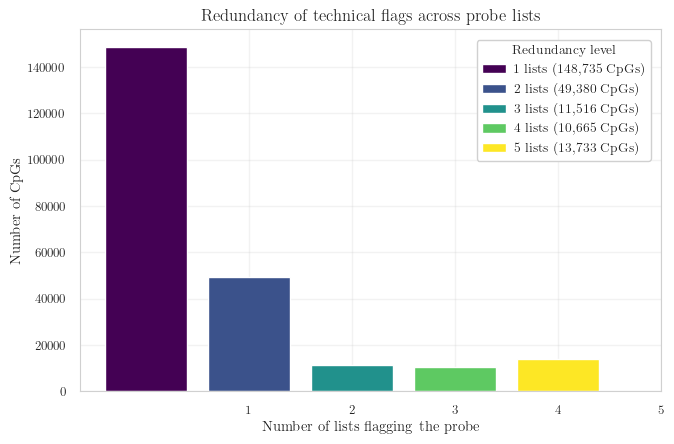

In [21]:
# HISTOGRAM — NUMBER OF TECHNICAL LISTS FLAGGING EACH CpG
# 1) Apply thesis style
apply_thesis_style(
    use_tex=True,
    legend_position="upper right",
    legend_outside=False
)

# 2) Convert to pandas
removed_pd = removed_summary_df.to_pandas()

# Determine the unique Source_Count values
unique_counts = sorted(removed_pd["Source_Count"].unique())
n_bins = len(unique_counts)

cmap = cm.get_cmap("viridis", n_bins)
colors = cmap(np.linspace(0, 1, n_bins))

# 3) Build figure
fig, ax = plt.subplots()

# Histogram (one bar per category, manually plotted for custom colors)
counts_per_k = removed_pd["Source_Count"].value_counts().sort_index()

bars = ax.bar(
    counts_per_k.index.astype(str),
    counts_per_k.values,
    color=colors,
    label=None
)

ax.set_xlabel("Number of lists flagging the probe")
ax.set_ylabel("Number of CpGs")
ax.set_title("Redundancy of technical flags across probe lists")

# X-axis labels centered
ax.set_xticks(counts_per_k.index.astype(int))
ax.set_xticklabels(counts_per_k.index.astype(int), rotation=0, ha="center")

# 4) Legend with explicit counts
legend_labels = [
    f"{k} lists ({counts_per_k.loc[k]:,} CpGs)"
    for k in counts_per_k.index
]

ax.legend(
    bars,
    legend_labels,
    title="Redundancy level",
    loc="upper right",
    frameon=True
)

fig.tight_layout()

# 5) Save as PDF
fig.savefig("gse69914_technical_lists_redundancy_histogram.pdf", bbox_inches="tight")
plt.show()


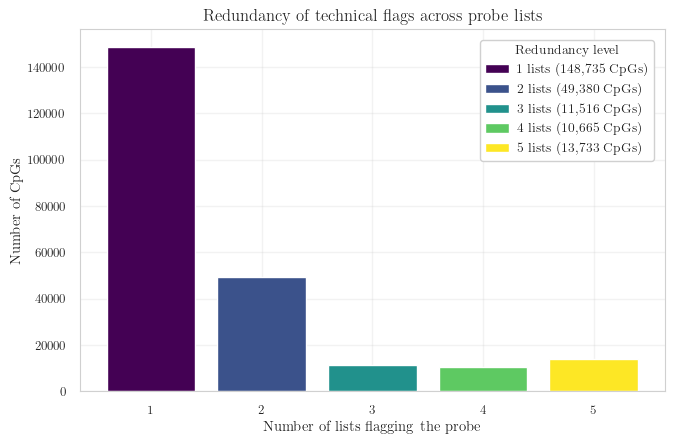

In [22]:
# HISTOGRAM — NUMBER OF TECHNICAL LISTS FLAGGING EACH CpG
# 1) Apply thesis style
apply_thesis_style(
    use_tex=True,
    legend_position="upper right",
    legend_outside=False
)

# 2) Convert to pandas
removed_pd = removed_summary_df.to_pandas()

# Counts per Source_Count (sorted)
counts_per_k = removed_pd["Source_Count"].value_counts().sort_index()

# X positions for bars: 0, 1, 2, ...
x = np.arange(len(counts_per_k))

# Viridis colors (one per redundancy level)
cmap = cm.get_cmap("viridis", len(counts_per_k))
colors = cmap(np.linspace(0, 1, len(counts_per_k)))

# 3) Build figure
fig, ax = plt.subplots()

bars = ax.bar(
    x,
    counts_per_k.values,
    color=colors
)

ax.set_xlabel("Number of lists flagging the probe")
ax.set_ylabel("Number of CpGs")
ax.set_title("Redundancy of technical flags across probe lists")

# X-axis: ticks at 0..n-1, labels are the actual Source_Count values (1,2,3,...)
ax.set_xticks(x)
ax.set_xticklabels(counts_per_k.index.astype(int), rotation=0, ha="center")

# 4) Legend with explicit counts
legend_labels = [
    f"{k} lists ({counts_per_k.loc[k]:,} CpGs)"
    for k in counts_per_k.index
]

ax.legend(
    bars,
    legend_labels,
    title="Redundancy level",
    loc="upper right",
    frameon=True
)

fig.tight_layout()

# 5) Save as PDF
fig.savefig("gse69914_technical_lists_redundancy_histogram.pdf", bbox_inches="tight")
plt.show()


In [23]:
print("working")

working


## STEP 2 — Invaiant Filtering on Normal+Adjacent

### CELL 2.1 — Invariance filtering

In [ ]:
# STEP 2 — INVARIANCE FILTERING 
# Configuration

LABEL_COL        = "label"
ID_COL           = "id_tissue"

NORMAL_LABELS    = [0]
ADJACENT_LABELS  = [1]
TUMOR_LABELS     = [2]

NA_LABELS        = NORMAL_LABELS + ADJACENT_LABELS   # 0 + 1
NT_LABELS        = NORMAL_LABELS + TUMOR_LABELS      # 0 + 2

R_BETA_THRESHOLDS = [0.01, 0.02, 0.05]
R_BETA_CUTOFF     = 0.05       # Edgar threshold (P90–P10 < 0.05)
HIST_BINS         = 120

beta_clean = beta_pl.clone()
beta_schema_cols = list(beta_clean.columns)

def get_cpg_cols(df: pl.DataFrame) -> list[str]:
    return [
        c for c in df.columns
        if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
    ]

def compute_r_beta_edgar(beta_df: pl.DataFrame, label_values: list[int]):
    """
    r_beta = P90(beta) - P10(beta) on the chosen subset (Edgar-style).
    """
    cpg_cols = get_cpg_cols(beta_df)
    subset = beta_df.filter(pl.col(LABEL_COL).is_in(label_values))
    subset_cpg = subset.select(cpg_cols)

    q90 = subset_cpg.select(pl.all().quantile(0.90)).to_numpy()[0, :]
    q10 = subset_cpg.select(pl.all().quantile(0.10)).to_numpy()[0, :]
    r_beta = q90 - q10

    return r_beta, cpg_cols

def summarize_thresholds(r_beta: np.ndarray, thresholds: list[float]):
    """
    Print and return how many CpGs fall below each threshold.
    """
    n = r_beta.size
    removed_counts = {}
    print("=== r_beta threshold study ===")
    for t in thresholds:
        cnt = int(np.sum(r_beta < t))
        removed_counts[t] = cnt
        print(f"t = {t:.3f}: removes {cnt:,}/{n:,} CpGs ({cnt/n:5.1%})")
    return removed_counts

def build_invariance_sets(r_beta, cpg_cols, cutoff):
    mask_keep = r_beta >= cutoff
    keep_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if keep}
    inv_cpgs  = {cpg_cols[i] for i, keep in enumerate(mask_keep) if not keep}
    return inv_cpgs, keep_cpgs

# --- simplification of gene-feature categories for a readable plot ---
def simplify_gene_feature(s: str) -> str:
    if s is None:
        return "Other"
    s = str(s)
    if "TSS200" in s:
        return "TSS200"
    if "TSS1500" in s:
        return "TSS1500"
    if "5'UTR" in s or "5UTR" in s:
        return "5'UTR"
    if "1stExon" in s:
        return "1stExon"
    if "Body" in s:
        return "Body"
    if "3'UTR" in s or "3UTR" in s:
        return "3'UTR"
    if "IGR" in s or "Intergenic" in s:
        return "Intergenic"
    return "Other"

def annotate_manifest_features(manifest: pl.DataFrame) -> pl.DataFrame:
    """
    Adds:
      - probe_id
      - gene_feature (raw)
      - gene_feature_simple (compact categories for plotting)
      - island_feature
    """
    # Probe ID column
    probe_col = next(
        (c for c in ("IlmnID", "Name", "probe_id", "ID_REF") if c in manifest.columns),
        None,
    )
    if probe_col is None:
        raise KeyError("No probe_id col found in manifest")

    manifest = manifest.with_columns(
        pl.col(probe_col).cast(pl.Utf8).alias("probe_id")
    )

    # Raw gene feature
    gene_col = next(
        (c for c in ("UCSC_RefGene_Group", "Gene_Feature", "Gene_Group") if c in manifest.columns),
        None,
    )
    if gene_col:
        manifest = manifest.with_columns(
            pl.col(gene_col).cast(pl.Utf8).alias("gene_feature")
        )
    else:
        manifest = manifest.with_columns(
            pl.lit("UNKNOWN").alias("gene_feature")
        )

    # CpG island feature
    island_col = next(
        (c for c in ("Relation_to_Island", "Island_Relation", "Island_Feature") if c in manifest.columns),
        None,
    )
    if island_col:
        manifest = manifest.with_columns(
            pl.col(island_col).cast(pl.Utf8).alias("island_feature")
        )
    else:
        manifest = manifest.with_columns(
            pl.lit("NO_ISLAND_INFO").alias("island_feature")
        )

    # Simple gene feature for plotting – everything in Polars, with pl.lit(...)
    gf = pl.col("gene_feature").fill_null("")

    manifest = manifest.with_columns(
        pl.when(gf.str.contains("TSS200"))
          .then(pl.lit("TSS200"))
        .when(gf.str.contains("TSS1500"))
          .then(pl.lit("TSS1500"))
        .when(gf.str.contains("5'UTR") | gf.str.contains("5UTR"))
          .then(pl.lit("5'UTR"))
        .when(gf.str.contains("1stExon"))
          .then(pl.lit("1stExon"))
        .when(gf.str.contains("Body"))
          .then(pl.lit("Body"))
        .when(gf.str.contains("3'UTR") | gf.str.contains("3UTR"))
          .then(pl.lit("3'UTR"))
        .when(gf.str.contains("IGR") | gf.str.contains("Intergenic"))
          .then(pl.lit("Intergenic"))
        .otherwise(pl.lit("Other"))
        .alias("gene_feature_simple")
    )

    return manifest.select(
        ["probe_id", "gene_feature", "gene_feature_simple", "island_feature"]
    )

def compute_feature_enrichment(universe_cpgs, subset_cpgs, manifest_feat, feature_col):
    mf = manifest_feat.filter(pl.col("probe_id").is_in(list(universe_cpgs)))

    bg = (
        mf.group_by(feature_col)
        .agg(pl.count().alias("bg_count"))
        .with_columns((pl.col("bg_count")/pl.col("bg_count").sum()).alias("bg_freq"))
    )

    mf_sub = mf.filter(pl.col("probe_id").is_in(list(subset_cpgs)))
    if mf_sub.height == 0:
        return pl.DataFrame({feature_col:[], "bg_count":[], "bg_freq":[],
                             "subset_count":[], "subset_freq":[], "fold_change":[]})

    sub = (
        mf_sub.group_by(feature_col)
        .agg(pl.count().alias("subset_count"))
        .with_columns((pl.col("subset_count")/pl.col("subset_count").sum()).alias("subset_freq"))
    )

    df = bg.join(sub, on=feature_col, how="left").with_columns([
        pl.col("subset_count").fill_null(0),
        pl.col("subset_freq").fill_null(0.0)
    ])

    df = df.with_columns(
        pl.when(pl.col("bg_freq") > 0)
        .then(pl.col("subset_freq")/pl.col("bg_freq"))
        .otherwise(None)
        .alias("fold_change")
    )

    return df.sort("fold_change", descending=True)

def plot_rbeta_distribution(beta_range, thresholds, removed_counts,
                            group_label, filename):
    """
    r_beta histogram with annotated cutoffs (thesis style), for N+A or N+T.
    """
    try:
        print(f"Generating r_beta distribution plot ({group_label})...")

        cmap = plt.cm.get_cmap("viridis")
        hist_color = cmap(0.70)

        if "apply_thesis_style" in globals():
            apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

        plt.figure()
        plt.hist(beta_range, bins=HIST_BINS, density=True, alpha=0.7,
                 color=hist_color, label=rf"$r_{{\beta}}$ on {group_label}")

        y_top = plt.ylim()[1]
        y_idx = 0.85
        colors = [cmap(0.10), cmap(0.45), cmap(0.90)]

        for t, color in zip(thresholds, colors):
            removed = removed_counts.get(t, None)
            label_text = f"Cutoff: {t:.3f}"
            if removed is not None:
                label_text += f"\nRemoved = {removed:,}"
            plt.axvline(t, linestyle="--", linewidth=2, color=color, label=f"Cutoff = {t:.3f}")
            plt.text(
                t + 0.002, y_top * y_idx, label_text,
                color=color,
                ha="left", va="top",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.2),
            )
            y_idx -= 0.15

        plt.xlabel(r"$r_{\beta} = P90(\beta) - P10(\beta)$ on " + group_label)
        plt.ylabel("Density")
        plt.xlim(0, 0.8)

        if "place_legend" in globals():
            place_legend(position="upper right")
        else:
            plt.legend(loc="upper right")

        plt.tight_layout()
        plt.savefig(filename, bbox_inches="tight")
        plt.show()

        print(f"Saved: {filename}")

    except Exception as e:
        print(f"Skipping r_beta plot for {group_label} due to error: {e}")


print("\n=== STEP A — Invariance filter: Normal + Adjacent ===")

r_beta_NA, cpg_cols = compute_r_beta_edgar(beta_clean, NA_LABELS)
print(f"Computed r_beta on N+A for {len(cpg_cols):,} CpGs")

removed_counts_NA = summarize_thresholds(r_beta_NA, R_BETA_THRESHOLDS)

inv_NA, keep_NA = build_invariance_sets(r_beta_NA, cpg_cols, R_BETA_CUTOFF)
print(f"Non-variable on N+A: {len(inv_NA):,} ({len(inv_NA)/len(cpg_cols):5.1%})")
print(f"Kept (variable) on N+A: {len(keep_NA):,}")

meta_cols = [c for c in beta_clean.columns if c not in cpg_cols]
keep_cpgs_sorted = sorted(list(keep_NA))
beta_final_preFS = beta_clean.select(meta_cols + keep_cpgs_sorted)
print(f"beta_final_preFS shape: {beta_final_preFS.shape}")


print("\n=== STEP B — Invariance filter: Normal + Tumor ===")

r_beta_NT, cpg_cols_NT = compute_r_beta_edgar(beta_clean, NT_LABELS)
assert cpg_cols_NT == cpg_cols, "Ordering mismatch CpGs"

removed_counts_NT = summarize_thresholds(r_beta_NT, R_BETA_THRESHOLDS)

inv_NT, keep_NT = build_invariance_sets(r_beta_NT, cpg_cols_NT, R_BETA_CUTOFF)

print(f"Non-variable on N+T: {len(inv_NT):,}")
print(f"Variable on N+T:     {len(keep_NT):,}")


print("\n=== STEP C — Set comparison (NA vs NT) ===")

I_stable    = inv_NA & inv_NT
I_breakdown = inv_NA - inv_NT
I_NT_only   = inv_NT - inv_NA

print(f"Stable (NA ∩ NT):     {len(I_stable):,}")
print(f"Breakdown (NA \\ NT):  {len(I_breakdown):,}")
print(f"NT-only:               {len(I_NT_only):,}")


# PLOT r_beta DISTRIBUTIONS (N+A and N+T)
plot_rbeta_distribution(
    beta_range     = r_beta_NA,
    thresholds     = R_BETA_THRESHOLDS,
    removed_counts = removed_counts_NA,
    group_label    = "Normal + Adjacent",
    filename       = "r_beta_distribution_NA_study.pdf",
)

plot_rbeta_distribution(
    beta_range     = r_beta_NT,
    thresholds     = R_BETA_THRESHOLDS,
    removed_counts = removed_counts_NT,
    group_label    = "Normal + Tumor",
    filename       = "r_beta_distribution_NT_study.pdf",
)



=== STEP A — Invariance filter: Normal + Adjacent ===
Computed r_beta on N+A for 251,483 CpGs
=== r_beta threshold study ===
t = 0.010: removes 3,728/251,483 CpGs ( 1.5%)
t = 0.020: removes 39,247/251,483 CpGs (15.6%)
t = 0.050: removes 100,683/251,483 CpGs (40.0%)
Non-variable on N+A: 100,683 (40.0%)
Kept (variable) on N+A: 150,800
beta_final_preFS shape: (407, 150802)

=== STEP B — Invariance filter: Normal + Tumor ===
=== r_beta threshold study ===
t = 0.010: removes 1,596/251,483 CpGs ( 0.6%)
t = 0.020: removes 27,247/251,483 CpGs (10.8%)
t = 0.050: removes 77,687/251,483 CpGs (30.9%)
Non-variable on N+T: 77,687
Variable on N+T:     173,796

=== STEP C — Set comparison (NA vs NT) ===
Stable (NA ∩ NT):     75,029
Breakdown (NA \ NT):  25,654
NT-only:               2,658
Generating r_beta distribution plot (Normal + Adjacent)...


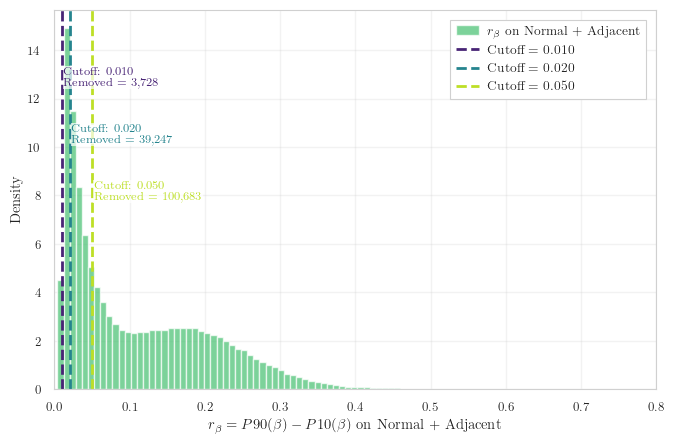

Saved: r_beta_distribution_NA_study.pdf
Generating r_beta distribution plot (Normal + Tumor)...


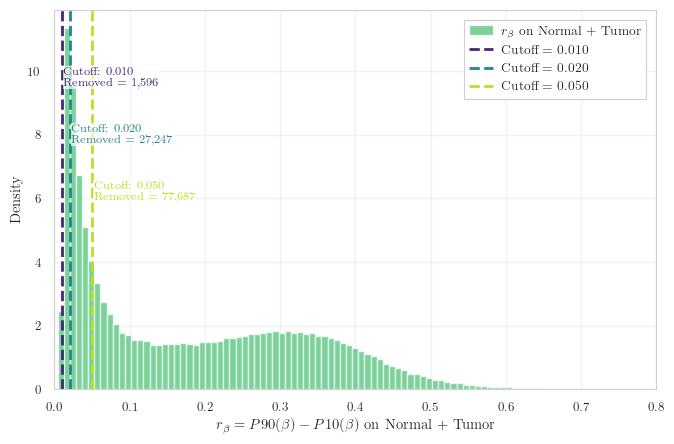

Saved: r_beta_distribution_NT_study.pdf


In [24]:
############################################################
# STEP 2 — INVARIANCE FILTERING + GENOMIC ENRICHMENT (EDGAR-STYLE)
# + PLOT PRINCIPALI PER LA TESI
############################################################

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ==============================
# CONFIGURAZIONE
# ==============================

LABEL_COL        = "label"
ID_COL           = "id_tissue"

NORMAL_LABELS    = [0]
ADJACENT_LABELS  = [1]
TUMOR_LABELS     = [2]

NA_LABELS        = NORMAL_LABELS + ADJACENT_LABELS   # 0 + 1
NT_LABELS        = NORMAL_LABELS + TUMOR_LABELS      # 0 + 2

R_BETA_THRESHOLDS = [0.01, 0.02, 0.05]
R_BETA_CUTOFF     = 0.05       # Edgar threshold (P90–P10 < 0.05)
HIST_BINS         = 120

beta_clean = beta_pl.clone()
beta_schema_cols = list(beta_clean.columns)

# ==============================
# HELPER FUNCTIONS
# ==============================

def get_cpg_cols(df: pl.DataFrame) -> list[str]:
    return [
        c for c in df.columns
        if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
    ]


def compute_r_beta_edgar(beta_df: pl.DataFrame, label_values: list[int]):
    """
    r_beta = P90(beta) - P10(beta) on the chosen subset (Edgar-style).
    """
    cpg_cols = get_cpg_cols(beta_df)
    subset = beta_df.filter(pl.col(LABEL_COL).is_in(label_values))
    subset_cpg = subset.select(cpg_cols)

    q90 = subset_cpg.select(pl.all().quantile(0.90)).to_numpy()[0, :]
    q10 = subset_cpg.select(pl.all().quantile(0.10)).to_numpy()[0, :]
    r_beta = q90 - q10

    return r_beta, cpg_cols


def summarize_thresholds(r_beta: np.ndarray, thresholds: list[float]):
    """
    Print and return how many CpGs fall below each threshold.
    """
    n = r_beta.size
    removed_counts = {}
    print("=== r_beta threshold study ===")
    for t in thresholds:
        cnt = int(np.sum(r_beta < t))
        removed_counts[t] = cnt
        print(f"t = {t:.3f}: removes {cnt:,}/{n:,} CpGs ({cnt/n:5.1%})")
    return removed_counts


def build_invariance_sets(r_beta, cpg_cols, cutoff):
    mask_keep = r_beta >= cutoff
    keep_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if keep}
    inv_cpgs  = {cpg_cols[i] for i, keep in enumerate(mask_keep) if not keep}
    return inv_cpgs, keep_cpgs


# --- semplificazione delle categorie gene-feature per un plot leggibile ---
def simplify_gene_feature(s: str) -> str:
    if s is None:
        return "Other"
    s = str(s)
    if "TSS200" in s:
        return "TSS200"
    if "TSS1500" in s:
        return "TSS1500"
    if "5'UTR" in s or "5UTR" in s:
        return "5'UTR"
    if "1stExon" in s:
        return "1stExon"
    if "Body" in s:
        return "Body"
    if "3'UTR" in s or "3UTR" in s:
        return "3'UTR"
    if "IGR" in s or "Intergenic" in s:
        return "Intergenic"
    return "Other"


def annotate_manifest_features(manifest: pl.DataFrame) -> pl.DataFrame:
    """
    Aggiunge:
      - probe_id
      - gene_feature (grezza)
      - gene_feature_simple (categorie compatte per il plot)
      - island_feature
    """
    # Colonna ID sonda
    probe_col = next(
        (c for c in ("IlmnID", "Name", "probe_id", "ID_REF") if c in manifest.columns),
        None,
    )
    if probe_col is None:
        raise KeyError("No probe_id col found in manifest")

    manifest = manifest.with_columns(
        pl.col(probe_col).cast(pl.Utf8).alias("probe_id")
    )

    # Gene feature "grezza"
    gene_col = next(
        (c for c in ("UCSC_RefGene_Group", "Gene_Feature", "Gene_Group") if c in manifest.columns),
        None,
    )
    if gene_col:
        manifest = manifest.with_columns(
            pl.col(gene_col).cast(pl.Utf8).alias("gene_feature")
        )
    else:
        manifest = manifest.with_columns(
            pl.lit("UNKNOWN").alias("gene_feature")
        )

    # CpG island feature
    island_col = next(
        (c for c in ("Relation_to_Island", "Island_Relation", "Island_Feature") if c in manifest.columns),
        None,
    )
    if island_col:
        manifest = manifest.with_columns(
            pl.col(island_col).cast(pl.Utf8).alias("island_feature")
        )
    else:
        manifest = manifest.with_columns(
            pl.lit("NO_ISLAND_INFO").alias("island_feature")
        )

    # Gene feature "semplice" per il plot – tutto in Polars, con pl.lit(...)
    gf = pl.col("gene_feature").fill_null("")

    manifest = manifest.with_columns(
        pl.when(gf.str.contains("TSS200"))
          .then(pl.lit("TSS200"))
        .when(gf.str.contains("TSS1500"))
          .then(pl.lit("TSS1500"))
        .when(gf.str.contains("5'UTR") | gf.str.contains("5UTR"))
          .then(pl.lit("5'UTR"))
        .when(gf.str.contains("1stExon"))
          .then(pl.lit("1stExon"))
        .when(gf.str.contains("Body"))
          .then(pl.lit("Body"))
        .when(gf.str.contains("3'UTR") | gf.str.contains("3UTR"))
          .then(pl.lit("3'UTR"))
        .when(gf.str.contains("IGR") | gf.str.contains("Intergenic"))
          .then(pl.lit("Intergenic"))
        .otherwise(pl.lit("Other"))
        .alias("gene_feature_simple")
    )

    return manifest.select(
        ["probe_id", "gene_feature", "gene_feature_simple", "island_feature"]
    )



def compute_feature_enrichment(universe_cpgs, subset_cpgs, manifest_feat, feature_col):
    mf = manifest_feat.filter(pl.col("probe_id").is_in(list(universe_cpgs)))

    bg = (
        mf.group_by(feature_col)
        .agg(pl.count().alias("bg_count"))
        .with_columns((pl.col("bg_count")/pl.col("bg_count").sum()).alias("bg_freq"))
    )

    mf_sub = mf.filter(pl.col("probe_id").is_in(list(subset_cpgs)))
    if mf_sub.height == 0:
        return pl.DataFrame({feature_col:[], "bg_count":[], "bg_freq":[],
                             "subset_count":[], "subset_freq":[], "fold_change":[]})

    sub = (
        mf_sub.group_by(feature_col)
        .agg(pl.count().alias("subset_count"))
        .with_columns((pl.col("subset_count")/pl.col("subset_count").sum()).alias("subset_freq"))
    )

    df = bg.join(sub, on=feature_col, how="left").with_columns([
        pl.col("subset_count").fill_null(0),
        pl.col("subset_freq").fill_null(0.0)
    ])

    df = df.with_columns(
        pl.when(pl.col("bg_freq") > 0)
        .then(pl.col("subset_freq")/pl.col("bg_freq"))
        .otherwise(None)
        .alias("fold_change")
    )

    return df.sort("fold_change", descending=True)


def plot_rbeta_distribution(beta_range, thresholds, removed_counts,
                            group_label, filename):
    """
    Istogramma r_beta con cutoff annotati (stile tesi), per N+A o N+T.
    """
    try:
        print(f"Generating r_beta distribution plot ({group_label})...")

        cmap = plt.cm.get_cmap("viridis")
        hist_color = cmap(0.70)

        if "apply_thesis_style" in globals():
            apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

        plt.figure()
        plt.hist(beta_range, bins=HIST_BINS, density=True, alpha=0.7,
                 color=hist_color, label=rf"$r_{{\beta}}$ on {group_label}")

        y_top = plt.ylim()[1]
        y_idx = 0.85
        colors = [cmap(0.10), cmap(0.45), cmap(0.90)]

        for t, color in zip(thresholds, colors):
            removed = removed_counts.get(t, None)
            label_text = f"Cutoff: {t:.3f}"
            if removed is not None:
                label_text += f"\nRemoved = {removed:,}"
            plt.axvline(t, linestyle="--", linewidth=2, color=color, label=f"Cutoff = {t:.3f}")
            plt.text(
                t + 0.002, y_top * y_idx, label_text,
                color=color,
                ha="left", va="top",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.2),
            )
            y_idx -= 0.15

        plt.xlabel(r"$r_{\beta} = P90(\beta) - P10(\beta)$ on " + group_label)
        plt.ylabel("Density")
        plt.xlim(0, 0.8)

        if "place_legend" in globals():
            place_legend(position="upper right")
        else:
            plt.legend(loc="upper right")

        plt.tight_layout()
        plt.savefig(filename, bbox_inches="tight")
        plt.show()

        print(f"Saved: {filename}")

    except Exception as e:
        print(f"Skipping r_beta plot for {group_label} due to error: {e}")


# ==============================
# STEP A — INVARIANCE FILTER ON NORMAL+ADJACENT
# ==============================

print("\n=== STEP A — Invariance filter: Normal + Adjacent ===")

r_beta_NA, cpg_cols = compute_r_beta_edgar(beta_clean, NA_LABELS)
print(f"Computed r_beta on N+A for {len(cpg_cols):,} CpGs")

removed_counts_NA = summarize_thresholds(r_beta_NA, R_BETA_THRESHOLDS)

inv_NA, keep_NA = build_invariance_sets(r_beta_NA, cpg_cols, R_BETA_CUTOFF)
print(f"Non-variable on N+A: {len(inv_NA):,} ({len(inv_NA)/len(cpg_cols):5.1%})")
print(f"Kept (variable) on N+A: {len(keep_NA):,}")

meta_cols = [c for c in beta_clean.columns if c not in cpg_cols]
keep_cpgs_sorted = sorted(list(keep_NA))
beta_final_preFS = beta_clean.select(meta_cols + keep_cpgs_sorted)
print(f"beta_final_preFS shape: {beta_final_preFS.shape}")


# ==============================
# STEP B — INVARIANCE ON NORMAL+TUMOR
# ==============================

print("\n=== STEP B — Invariance filter: Normal + Tumor ===")

r_beta_NT, cpg_cols_NT = compute_r_beta_edgar(beta_clean, NT_LABELS)
assert cpg_cols_NT == cpg_cols, "Ordering mismatch CpGs"

removed_counts_NT = summarize_thresholds(r_beta_NT, R_BETA_THRESHOLDS)

inv_NT, keep_NT = build_invariance_sets(r_beta_NT, cpg_cols_NT, R_BETA_CUTOFF)

print(f"Non-variable on N+T: {len(inv_NT):,}")
print(f"Variable on N+T:     {len(keep_NT):,}")


# ==============================
# STEP C — SET COMPARISON
# ==============================

print("\n=== STEP C — Set comparison (NA vs NT) ===")

I_stable    = inv_NA & inv_NT
I_breakdown = inv_NA - inv_NT
I_NT_only   = inv_NT - inv_NA

print(f"Stable (NA ∩ NT):     {len(I_stable):,}")
print(f"Breakdown (NA \\ NT):  {len(I_breakdown):,}")
print(f"NT-only:               {len(I_NT_only):,}")


# ==============================
# PLOT r_beta DISTRIBUTIONS (N+A and N+T)
# ==============================

plot_rbeta_distribution(
    beta_range     = r_beta_NA,
    thresholds     = R_BETA_THRESHOLDS,
    removed_counts = removed_counts_NA,
    group_label    = "Normal + Adjacent",
    filename       = "r_beta_distribution_NA_study.pdf",
)

plot_rbeta_distribution(
    beta_range     = r_beta_NT,
    thresholds     = R_BETA_THRESHOLDS,
    removed_counts = removed_counts_NT,
    group_label    = "Normal + Tumor",
    filename       = "r_beta_distribution_NT_study.pdf",
)


### CELL 2.2 — Genomic Enrichment


=== GENOMIC ENRICHMENT ===


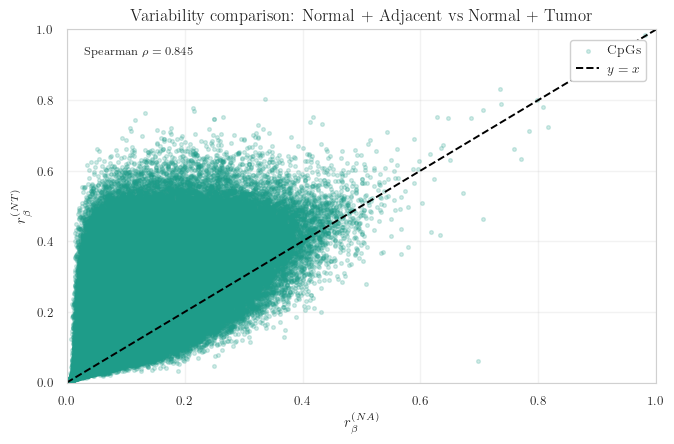


=== Edgar-style invariance filtering + enrichment COMPLETE ===


In [36]:
# GENOMIC ENRICHMENT  
print("\n=== GENOMIC ENRICHMENT ===")
manifest_feat = annotate_manifest_features(manifest)
universe = set(cpg_cols)  # use the simplified column to have few, clear categories
gene_enrich_invariant = compute_feature_enrichment(universe, inv_NA, manifest_feat, "gene_feature_simple")
gene_enrich_kept = compute_feature_enrichment(universe, keep_NA, manifest_feat, "gene_feature_simple")

# SCATTER rβ(N+A) vs rβ(N+T) — identical style
if "apply_thesis_style" in globals():
    apply_thesis_style()

plt.figure()   # let the style sheet control figure size

# Scatter (rasterized points for lighter PDF)
plt.scatter(
    r_beta_NA,
    r_beta_NT,
    s=7,
    alpha=0.20,
    color=plt.cm.viridis(0.55),
    label="CpGs",
    rasterized=True   # 👈 convert scatter points to bitmap inside the vector PDF
)

# Identity line
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.4,
    label=r"$y = x$"
)

# Spearman
rho_s, p_s = spearmanr(r_beta_NA, r_beta_NT)
ax = plt.gca()
ax.text(
    0.03, 0.95,
    rf"Spearman $\rho = {rho_s:.3f}$",
    transform=ax.transAxes,
    ha="left",
    va="top"
)

# Labels
plt.xlabel(r"$r_{\beta}^{(NA)}$")
plt.ylabel(r"$r_{\beta}^{(NT)}$")
plt.title("Variability comparison: Normal + Adjacent vs Normal + Tumor")

plt.legend(loc="upper right")
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)

plt.tight_layout()
# dpi controls the resolution of the rasterized layer inside the PDF
plt.savefig("plot_scatter_rbeta_NA_vs_NT.pdf", bbox_inches="tight", dpi=200)
plt.show()


# BARPLOT ENRICHMENT GENE FEATURES (INVARIANT CpGs)
df_enrich = gene_enrich_invariant.to_pandas()

# cleaning & sorting
df_enrich = df_enrich.dropna(subset=["gene_feature_simple", "fold_change"])
df_enrich = df_enrich[df_enrich["gene_feature_simple"] != ""]
df_enrich = df_enrich.sort_values("fold_change", ascending=False)

# select the top categories
TOP_K = 8
df_plot = df_enrich.head(TOP_K)

if len(df_plot) > 0:

    # === thesis style ===
    if "apply_thesis_style" in globals():
        apply_thesis_style()

    plt.figure()

    # barplot
    bars = plt.bar(
        df_plot["gene_feature_simple"],
        df_plot["fold_change"],
        color=plt.cm.viridis(0.65)
    )

    # background line = 1
    plt.axhline(1.0, color="black", linestyle="--", linewidth=1.4, label="Background")

    # centered labels (no rotation)
    plt.xticks(
        ticks=range(len(df_plot)),
        labels=df_plot["gene_feature_simple"],
        rotation=0,
        ha="center"
    )

    plt.ylabel("Fold-change enrichment")
    plt.title("Gene-feature enrichment of invariant CpGs (Normal + Adjacent)")
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig("plot_enrichment_gene_invariant.pdf", bbox_inches="tight")
    plt.show()

else:
    print("WARNING: No valid gene features found for enrichment plot")

print("\n=== Edgar-style invariance filtering + enrichment COMPLETE ===")


### CELL 2.3 — Integration of Edgar's invariants with Breast Invariants

Blood invariants:    114,204
Buccal invariants:   120,009
Placenta invariants: 101,367

Universal invariants (Blood ∩ Buccal ∩ Placenta): 42,315

U ∩ invariants Normal+Adjacent:  30,251
U ∩ invariants Normal+Tumor:     28,351
U ∩ breakdown (lost stability in Tumor): 2,010
Invariants Normal+Adjacent, non-universal: 70,432
Invariants Normal+Tumor, non-universal:    49,336
Saved U_universal_edgar.csv (42,315 CpGs).
Saved U_intersect_inv_NA.csv (30,251 CpGs).
Saved U_intersect_inv_NT.csv (28,351 CpGs).
Saved U_breakdown_lost_in_tumor.csv (2,010 CpGs).
Saved inv_NA_not_universal.csv (70,432 CpGs).
Saved inv_NT_not_universal.csv (49,336 CpGs).


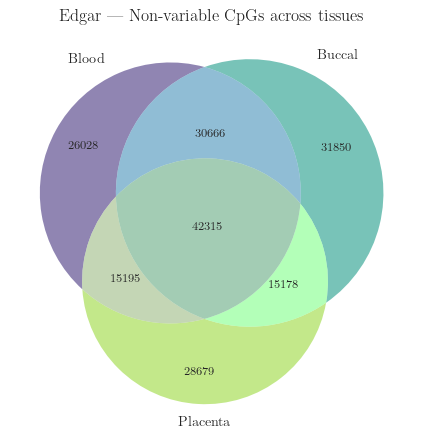

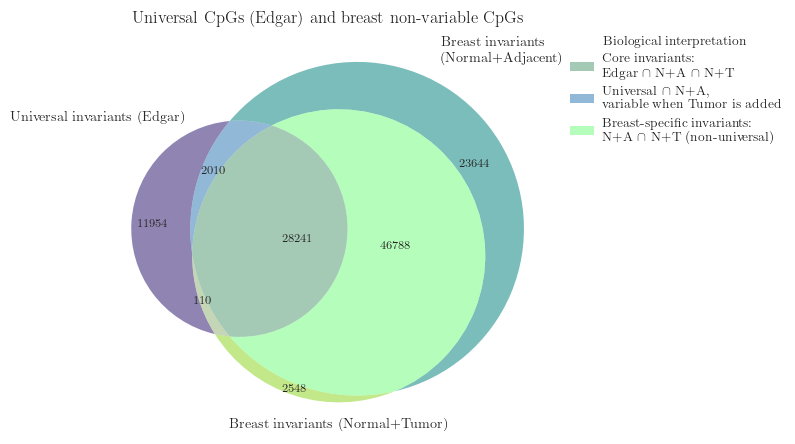


=== Comparison with Edgar completed successfully ===


In [26]:
# INTEGRATION OF EDGAR'S INVARIANTS WITH BREAST INVARIANTS
# Load Blood / Buccal / Placenta
blood = set(pd.read_csv(
    "/kaggle/input/invariant-blood-cpgs-csv/Invariant_Blood_CpGs.csv"
)["CpG"])
buccal = set(pd.read_csv(
    "/kaggle/input/invariant-buccal-cpgs-csv/Invariant_Buccal_CpGs.csv"
)["CpG"])
placenta = set(pd.read_csv(
    "/kaggle/input/invariant-placenta-cpgs-csv/Invariant_Placenta_CpGs.csv"
)["CpG"])

print(f"Blood invariants:    {len(blood):,}")
print(f"Buccal invariants:   {len(buccal):,}")
print(f"Placenta invariants: {len(placenta):,}")


# Universal invariants
U = blood & buccal & placenta
print(f"\nUniversal invariants (Blood ∩ Buccal ∩ Placenta): {len(U):,}")


# Intersections with inv_NA, inv_NT, I_breakdown, I_stable
# Universal invariants that are also non-variable in Normal+Adjacent
U_NA = U & inv_NA
print(f"\nU ∩ invariants Normal+Adjacent:  {len(U_NA):,}")

# Universal invariants that remain non-variable in Normal+Tumor
U_NT = U & inv_NT
print(f"U ∩ invariants Normal+Tumor:     {len(U_NT):,}")

# Universal invariants that LOSE stability when Tumor is added
U_breakdown = U & I_breakdown
print(f"U ∩ breakdown (lost stability in Tumor): {len(U_breakdown):,}")

# CpGs non-variable in breast (Normal+Adjacent) but not in other tissues
NA_not_U = inv_NA - U
print(f"Invariants Normal+Adjacent, non-universal: {len(NA_not_U):,}")

# CpGs non-variable in breast (Normal+Tumor) but not in other tissues
NT_not_U = inv_NT - U
print(f"Invariants Normal+Tumor, non-universal:    {len(NT_not_U):,}")

# CSV export
def export_set(name, s):
    df = pd.DataFrame({"CpG_ID": sorted(list(s))})
    df.to_csv(f"{name}.csv", index=False)
    print(f"Saved {name}.csv ({len(s):,} CpGs).")

export_set("U_universal_edgar", U)
export_set("U_intersect_inv_NA", U_NA)
export_set("U_intersect_inv_NT", U_NT)
export_set("U_breakdown_lost_in_tumor", U_breakdown)
export_set("inv_NA_not_universal", NA_not_U)
export_set("inv_NT_not_universal", NT_not_U)


# Venn diagrams (thesis style, biological legend)
# EDGAR INVARIANTS

if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

# Create figure + axis explicitly
fig, ax = plt.subplots()
fig.set_size_inches(6.8, 4.5)   

# Strongly separated viridis colors
c_blood  = plt.cm.viridis(0.15)
c_buccal = plt.cm.viridis(0.55)
c_plac   = plt.cm.viridis(0.85)

v = venn3(
    subsets=(
        len(blood - buccal - placenta),            # 100
        len(buccal - blood - placenta),            # 010
        len(blood & buccal - placenta),            # 110
        len(placenta - blood - buccal),            # 001
        len(blood & placenta - buccal),            # 101
        len(buccal & placenta - blood),            # 011
        len(U),                                    # 111
    ),
    set_labels=("Blood", "Buccal", "Placenta"),
    set_colors=(c_blood, c_buccal, c_plac),
    alpha=0.60,
    ax=ax,   
)

ax.set_title("Edgar — Non-variable CpGs across tissues")

fig.tight_layout()
fig.savefig("venn_edgar_invariants.pdf", bbox_inches="tight")
plt.show()


# Universal Edgar vs Breast Invariants (N+A, N+T)
if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

plt.figure()  

# Distinct viridis colors
c_univ = plt.cm.viridis(0.15)
c_NA   = plt.cm.viridis(0.50)
c_NT   = plt.cm.viridis(0.85)

v2 = venn3(
    subsets=(
        len(U - inv_NA - inv_NT),                  # 100: Universal only
        len(inv_NA - U - inv_NT),                  # 010: Breast N+A only
        len((U & inv_NA) - inv_NT),                # 110: U ∩ N+A (not N+T)
        len(inv_NT - U - inv_NA),                  # 001: Breast N+T only
        len((U & inv_NT) - inv_NA),                # 101: U ∩ N+T (not N+A)
        len((inv_NA & inv_NT) - U),                # 011: N+A ∩ N+T (breast-specific)
        len(U & inv_NA & inv_NT),                  # 111: core invariants (all three)
    ),
    set_labels=(
        "Universal invariants (Edgar)",
        "Breast invariants \n(Normal+Adjacent)",
        "Breast invariants (Normal+Tumor)",
    ),
    set_colors=(c_univ, c_NA, c_NT),
    alpha=0.60,
)

plt.title("Universal CpGs (Edgar) and breast non-variable CpGs")


# -------- BIOLOGICAL LEGEND FOR THE SECOND VENN --------
# region IDs:
# '111' -> U ∩ inv_NA ∩ inv_NT    (core invariants)
# '110' -> U ∩ inv_NA \ inv_NT    (universal + N+A, lost in Tumor)
# '011' -> inv_NA ∩ inv_NT \ U    (breast-specific invariants)

patch_core      = v2.get_patch_by_id("111")
patch_univ_NA   = v2.get_patch_by_id("110")
patch_breast_sp = v2.get_patch_by_id("011")

legend_patches = []
legend_labels  = []

def add_patch(patch, label):
    if patch is not None:
        fc = patch.get_facecolor()
        legend_patches.append(Patch(facecolor=fc, edgecolor="none"))
        legend_labels.append(label)

# 3 biologically relevant regions
add_patch(
    patch_core,
    "Core invariants:\nEdgar $\cap$ N+A $\\cap$ N+T",
)

add_patch(
    patch_univ_NA,
    "Universal $\cap$ N+A,\nvariable when Tumor is added",
)

add_patch(
    patch_breast_sp,
    "Breast-specific invariants:\nN+A $\cap$ N+T (non-universal)",
)

if legend_patches:
    plt.legend(
        legend_patches,
        legend_labels,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=False,
        title="Biological interpretation",
    )

plt.tight_layout()
plt.savefig("venn_universal_vs_NA_vs_NT.pdf", bbox_inches="tight")
plt.show()

print("\n=== Comparison with Edgar completed successfully ===")


### CELL 2.4 — Apply invariance + Summary

In [27]:
# APPLY INVARIANCE THRESHOLD (N+A) + UPDATE REMOVAL SUMMARY WITH EDGAR INVARIANTS
# 1) Apply final THRESHOLD and build keep/remove sets
THRESH_TO_USE = R_BETA_CUTOFF  # 0.05, Edgar threshold
n_total = len(cpg_cols)

remove_cpgs_invariant = inv_NA      # CpGs non-variable on N+A
keep_cpgs = keep_NA                 # CpGs variable on N+A

print(f"\nApplied invariance threshold t = {THRESH_TO_USE:.3f} on Normal+Adjacent:")
print(f"  Removed (non-variable on N+A): {len(remove_cpgs_invariant):,} CpGs")
print(f"  Kept (variable on N+A):        {len(keep_cpgs):,} CpGs")

# 2) Build beta_final_preFS (post-technical, filtered CpGs, all samples)
meta_cols = [c for c in beta_clean.columns if c not in cpg_cols]
keep_cpgs_sorted = sorted(list(keep_cpgs))

beta_final_preFS = beta_clean.select(meta_cols + keep_cpgs_sorted)

print("\nFinal matrix for pre-feature-selection stage defined:")
print(f"  beta_final_preFS — shape: {beta_final_preFS.shape[0]:,} samples × {beta_final_preFS.shape[1]-len(meta_cols):,} CpGs")
print("  (beta-values, post-technical, filtered on N+A variability)")



Applied invariance threshold t = 0.050 on Normal+Adjacent:
  Removed (non-variable on N+A): 100,683 CpGs
  Kept (variable on N+A):        150,800 CpGs

Final matrix for pre-feature-selection stage defined:
  beta_final_preFS — shape: 407 samples × 150,800 CpGs
  (beta-values, post-technical, filtered on N+A variability)


SchemaError: type Int64 is incompatible with expected type Int32

In [28]:
# 3) Update removed CpGs
# Load previous summary (technical filters only)
removed_summary_df = pl.read_csv("removed_cpgs_all_filters_summary.csv")

# If column already exists (re-runs), keep it; otherwise create with 0.
if "From_Edgar_Invariance" not in removed_summary_df.columns:
    removed_summary_df = removed_summary_df.with_columns(
        pl.lit(0).alias("From_Edgar_Invariance")
    )

# Mark CpGs that are invariant according to Edgar-style N+A filter
removed_summary_df = removed_summary_df.with_columns(
    pl.when(pl.col("CpG_ID").is_in(sorted(remove_cpgs_invariant)))
      .then(1)
      .otherwise(pl.col("From_Edgar_Invariance"))
      .alias("From_Edgar_Invariance")
)

# Add rows for CpGs removed ONLY by invariance (not present in previous filters)
already_listed = set(removed_summary_df["CpG_ID"].to_list())
new_only_invariance = sorted(remove_cpgs_invariant - already_listed)

if new_only_invariance:
    new_rows = []
    for cg in new_only_invariance:
        new_rows.append(
            {
                "CpG_ID": cg,
                "From_Naeem": 0,
                "From_Pidsley": 0,
                "From_Zhou": 0,
                "From_ChenX": 0,
                "From_McCartney": 0,
                "From_Non_CpG": 0,
                "From_XY": 0,
                "From_Edgar_Invariance": 1,
                # placeholder; will be overwritten when we recompute Source_Count
                "Source_Count": 1,
            }
        )

    # Build DataFrame and cast it to the same schema as removed_summary_df
    new_df = pl.DataFrame(new_rows)
    new_df = new_df.cast(removed_summary_df.schema)
    new_df = new_df.select(removed_summary_df.columns)

    # Now concatenation will not raise a schema error
    removed_summary_df = pl.concat([removed_summary_df, new_df], how="vertical")

# Recompute Source_Count including the new column
flag_cols = [
    "From_Naeem",
    "From_Pidsley",
    "From_Zhou",
    "From_ChenX",
    "From_McCartney",
    "From_Non_CpG",
    "From_XY",
    "From_Edgar_Invariance",
]

removed_summary_df = removed_summary_df.with_columns(
    sum(pl.col(c) for c in flag_cols).alias("Source_Count")
)

# Sort and overwrite the original CSV
removed_summary_df = removed_summary_df.sort(
    ["Source_Count", "CpG_ID"], descending=[True, False]
)

removed_summary_df.write_csv("removed_cpgs_all_filters_summary.csv")

print("\nUpdated 'removed_cpgs_all_filters_summary.csv' with Edgar invariance flag:")
print("  • Added column: From_Edgar_Invariance")
print("  • Source_Count now includes invariance filter")


# 4) STEP SUMMARY

removed_pct = (len(remove_cpgs_invariant) / n_total) * 100.0 if n_total > 0 else 0.0

print("\n=== STEP 3B — Invariance Filter Summary (Normal + Adjacent) ===")
print(f"Total CpGs analysed (N+A):          {n_total:,}")
print(f"Invariance threshold r_beta >= {THRESH_TO_USE:.3f}")
print(f"CpGs removed (low variability N+A): {len(remove_cpgs_invariant):,} ({removed_pct:5.1f}%)")
print(f"CpGs kept:                          {len(keep_cpgs):,}")
print("Matrices ready:")
print("  • beta_final_preFS    (beta-values, post-technical, filtered)")
print("Per-CpG removal summary updated with Edgar invariance flag.")
print("===============================================================")



Updated 'removed_cpgs_all_filters_summary.csv' with Edgar invariance flag:
  • Added column: From_Edgar_Invariance
  • Source_Count now includes invariance filter

=== STEP 3B — Invariance Filter Summary (Normal + Adjacent) ===
Total CpGs analysed (N+A):          251,483
Invariance threshold r_beta >= 0.050
CpGs removed (low variability N+A): 100,683 ( 40.0%)
CpGs kept:                          150,800
Matrices ready:
  • beta_final_preFS    (beta-values, post-technical, filtered)
Per-CpG removal summary updated with Edgar invariance flag.


## STEP 3 — Conversion β → M 

### CELL 3.1 — Preparation step

In [39]:
# DEFINE BETA_CLEAN MATRIX
# Set beta_clean as the post-technical filtering beta matrix (N + A + T).

beta_clean = beta_final_preFS  # From Step 1
beta_cpg_cols = [
    c for c in beta_clean.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]
meta_cols = [c for c in ("id_tissue", "label") if c in beta_clean.columns]

print("beta_clean shape:", beta_clean.shape)
print("beta_clean samples:", beta_clean.height)
print("beta_clean CpGs:", len(beta_cpg_cols))
print("beta_clean meta columns:", meta_cols)


beta_clean shape: (407, 150802)
beta_clean samples: 407
beta_clean CpGs: 150800
beta_clean meta columns: ['id_tissue', 'label']


In [40]:
# DEFINE EPS AND M-VALUE TRANSFORM
# Ensure EPS and compute_M_expr are defined for Beta → M conversion.

if "EPS" not in globals():
    EPS = 1e-6  # Numeric stability for Beta→M

def compute_M_expr(colname: str, eps: float = EPS) -> pl.Expr:
    """
    Compute M-value expression for a given CpG column:
    M = log2( (beta + eps) / (1 - beta + eps) ).
    Returns a Polars expression suitable for with_columns().
    """
    b = pl.col(colname).cast(pl.Float64)
    b = b.clip(eps, 1.0 - eps)
    return ((b + eps) / (1.0 - b + eps)).log(2.0).cast(pl.Float32)


In [31]:
# PREPARE CPG COLUMNS AND LAZYFRAME
# Identify CpG columns and construct a LazyFrame from beta_clean.

beta_schema_cols = list(beta_clean.columns)
cpg_cols = [
    c for c in beta_schema_cols
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]

assert len(cpg_cols) > 0, "No CpG columns found in beta_clean."
assert "id_tissue" in beta_schema_cols and "label" in beta_schema_cols, "Expected 'id_tissue' and 'label' in beta_clean."

lf_beta_clean = beta_clean.lazy()
print(f"CpG columns to be transformed to M-values: {len(cpg_cols)}")


CpG columns to be transformed to M-values: 150800


### CELL 3.2 — Build M matrix and export it

In [41]:
# BUILD M_clean LAZYFRAME
# Apply Beta → M transformation to all CpG columns, keeping metadata unchanged.

m_exprs = [compute_M_expr(c).alias(c) for c in cpg_cols]
M_clean = lf_beta_clean.with_columns(m_exprs)
print("M_clean LazyFrame defined (same schema as beta_clean for CpGs).")

# FILTER M_clean TO KEEP ONLY LABELS 0, 1, 2
VALID_LABELS = [0, 1, 2]

M_clean = M_clean.filter(
    pl.col("label").is_in(VALID_LABELS)
)

# Recompute shape after filtering
n_rows = M_clean.select(pl.len()).collect().item()
n_cols = len(M_clean.schema)

print("M_clean filtered to labels 0/1/2")
print("M_clean shape after filtering:", (n_rows, n_cols))


M_clean LazyFrame defined (same schema as beta_clean for CpGs).
M_clean filtered to labels 0/1/2
M_clean shape after filtering: (397, 150802)


In [45]:
# SAVE M_clean TO PARQUET
# Save M_clean as Parquet (LZ4) without fully materializing if possible.

OUT_PARQUET_M = "/kaggle/working/M_values_clean_lz4.parquet"

try:
    M_clean.sink_parquet(OUT_PARQUET_M, compression="lz4", maintain_order=True)
    print(f"Saved M_clean to Parquet (sink_parquet): {OUT_PARQUET_M}")
except Exception as e:
    print(f"Warning: sink_parquet failed with {e}. Falling back to collect().")
    df_m = M_clean.collect(streaming=True)
    df_m.write_parquet(OUT_PARQUET_M, compression="lz4")
    del df_m
    print(f"Saved M_clean to Parquet via collect(): {OUT_PARQUET_M}")


Saved M_clean to Parquet (sink_parquet): /kaggle/working/M_values_clean_lz4.parquet


### CELL 3.3 — Sanity check and summary

In [46]:
# OPTIONAL MATERIALIZATION CHECK
# Collect a small sample to verify that M_clean looks reasonable.

M_head = M_clean.select(meta_cols + cpg_cols[:5]).collect().head(3)
print("Preview of M_clean (first 3 samples, first 5 CpGs):")
print(M_head)


Preview of M_clean (first 3 samples, first 5 CpGs):
shape: (3, 7)
┌────────────┬───────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ id_tissue  ┆ label ┆ cg00000029 ┆ cg00000165 ┆ cg00000236 ┆ cg00000289 ┆ cg00000292 │
│ ---        ┆ ---   ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str        ┆ i8    ┆ f32        ┆ f32        ┆ f32        ┆ f32        ┆ f32        │
╞════════════╪═══════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ GSM1712367 ┆ 2     ┆ -1.522132  ┆ -1.600669  ┆ 3.212432   ┆ -0.104325  ┆ 2.387851   │
│ GSM1712368 ┆ 1     ┆ -2.022162  ┆ -0.931888  ┆ 2.728189   ┆ 0.181265   ┆ 1.239819   │
│ GSM1712369 ┆ 0     ┆ -1.397192  ┆ -1.859563  ┆ 2.370728   ┆ 0.15242    ┆ 1.672821   │
└────────────┴───────┴────────────┴────────────┴────────────┴────────────┴────────────┘


In [47]:
# STEP 3 SUMMARY
# Summarize Beta → M conversion and define final objects for downstream steps.

print("\n=== STEP 3 — β → M Summary ===")
print(f"beta_clean samples: {beta_clean.height}")
print(f"beta_clean CpGs:    {len(cpg_cols)}")
print(f"M_clean stored as LazyFrame and saved to: {OUT_PARQUET_M}")
print("Decision: M-values will be used for statistical modeling (limma, ComBat, etc.),")
print("while beta_clean will be kept for biological interpretation (plots, heatmaps, boxplots).")
print("==============================================================")



=== STEP 3 — β → M Summary ===
beta_clean samples: 407
beta_clean CpGs:    150800
M_clean stored as LazyFrame and saved to: /kaggle/working/M_values_clean_lz4.parquet
Decision: M-values will be used for statistical modeling (limma, ComBat, etc.),
while beta_clean will be kept for biological interpretation (plots, heatmaps, boxplots).


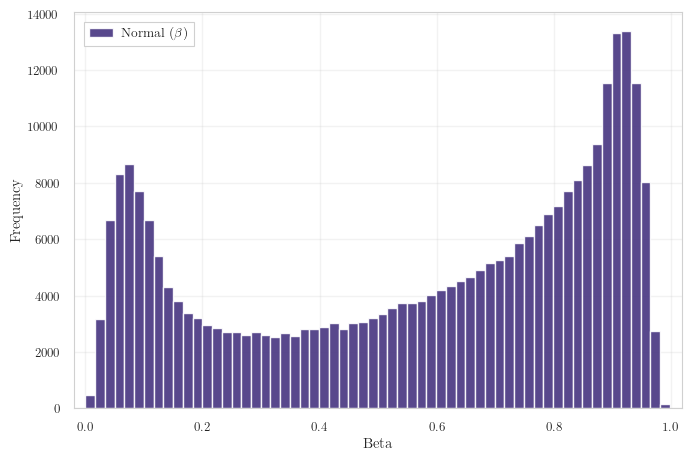

✅ Saved: hist_normal_beta.pdf


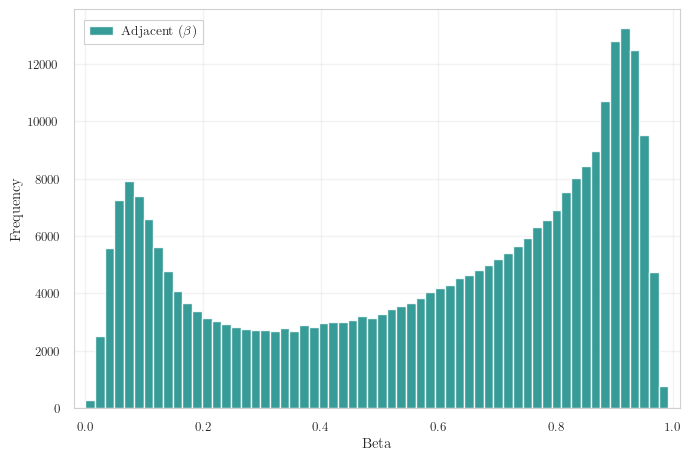

✅ Saved: hist_adjacent_beta.pdf


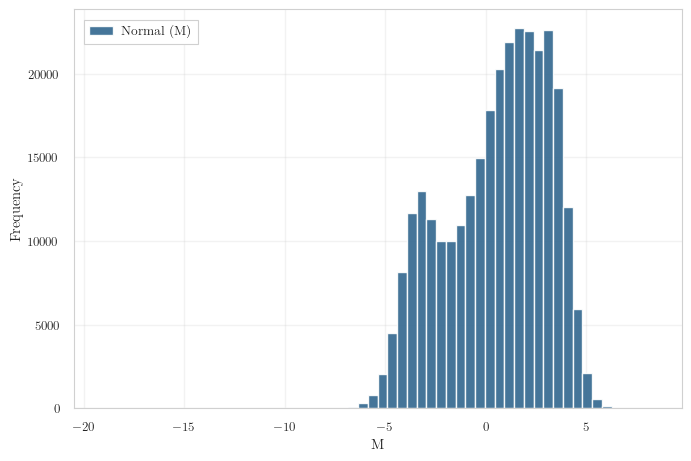

✅ Saved: hist_normal_m.pdf


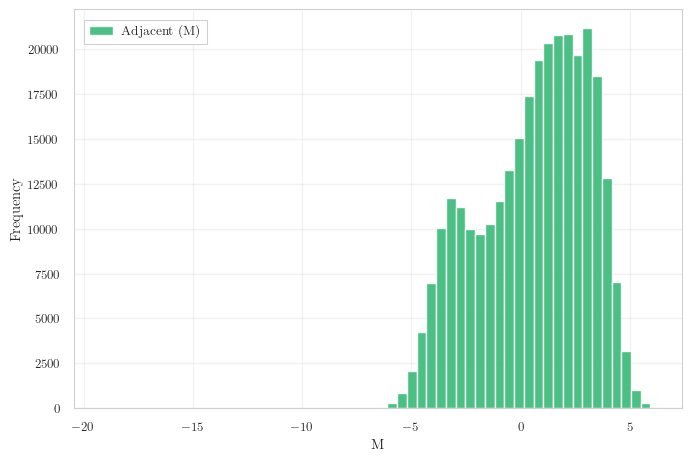

✅ Saved: hist_adjacent_m.pdf


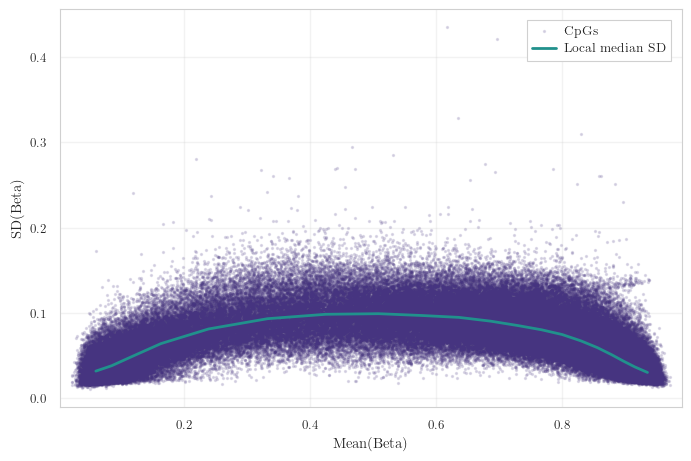

✅ Saved: msd_normal_beta.pdf


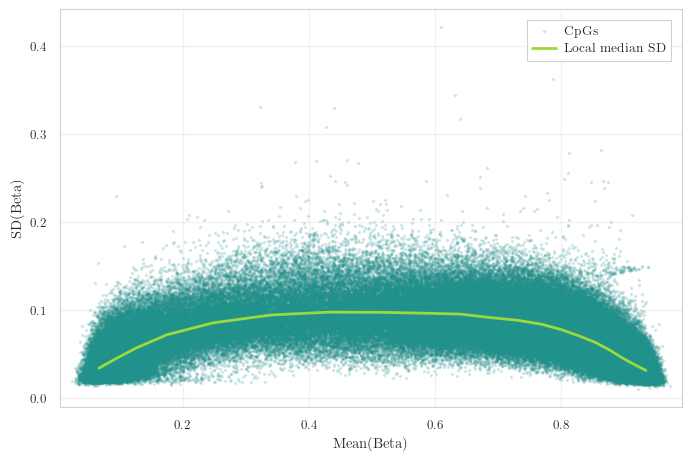

✅ Saved: msd_adjacent_beta.pdf


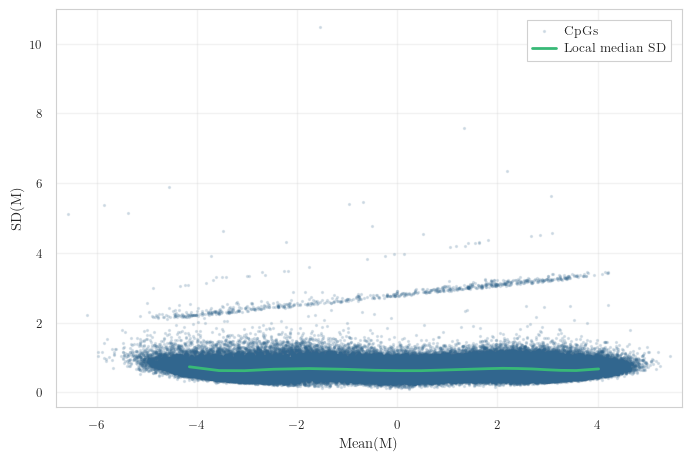

✅ Saved: msd_normal_m.pdf


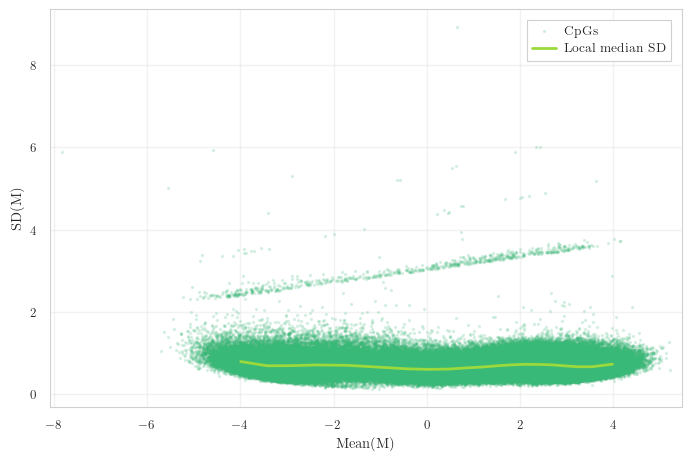

✅ Saved: msd_adjacent_m.pdf


In [38]:
############################################################
# STEP 3 — BETA VS M: GLOBAL DISTRIBUTIONS AND MEAN–SD
#           (NORMAL VS ADJACENT)
############################################################

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

# Fixed colormap (consistent with previous figures)
viridis = plt.cm.viridis(np.linspace(0.15, 0.85, 5))
USE_TEX = True  # passed to apply_thesis_style

# ============================================
# HELPERS FOR DATA COLLECTION
# ============================================
def _safe_cpg_cols(table, cpg_cols):
    """
    Ensure that all CpG columns exist in the current DataFrame/LazyFrame.
    Returns only valid columns and warns if any are missing.
    """
    cols = set(table.columns)
    ok = [c for c in cpg_cols if c in cols]
    missing = [c for c in cpg_cols if c not in cols]
    if missing:
        print(f"⚠️  {len(missing)} CpGs not found and will be ignored (e.g., {missing[:5]})")
    if not ok:
        raise ValueError("No valid CpG columns remaining after filtering.")
    return ok


def collect_group_betas(table, cpg_cols, label_set, max_points=300_000, seed=42):
    """
    Collect all β-values (all CpGs × all samples) for the given label_set.
    Optionally subsample to speed up plots.
    """
    lf = table.lazy() if isinstance(table, pl.DataFrame) else table
    cpg_cols = _safe_cpg_cols(lf, cpg_cols)

    df = (
        lf.filter(pl.col("label").is_in(label_set))
          .select(cpg_cols)
          .collect()
    )
    arr = df.to_numpy().astype(np.float32, copy=False).ravel()
    arr = arr[np.isfinite(arr)]
    if (max_points is not None) and (arr.size > max_points):
        rng = np.random.default_rng(seed)
        arr = rng.choice(arr, size=max_points, replace=False)
    return arr


# ============================================
# BETA → M (NUMPY VERSION FOR HISTOGRAMS)
# ============================================
def compute_M_numpy(beta_vec, eps: float = EPS):
    b = np.clip(beta_vec.astype(float), eps, 1.0 - eps)
    return np.log2(b / (1.0 - b))


# ============================================
# BINNED MEDIANS FOR MEAN–SD CURVES
# ============================================
def _binned_median_sd(means, sds, n_bins=20):
    df = pd.DataFrame({"mean": means, "sd": sds}).dropna().sort_values("mean")
    if len(df) == 0:
        return np.array([]), np.array([])
    bins = np.array_split(df, n_bins)
    x = [b["mean"].median() for b in bins if len(b)]
    y = [b["sd"].median() for b in bins if len(b)]
    return np.array(x), np.array(y)


def compute_group_mean_sd_polars_multi(table, cpg_cols, label_values, metric="beta", eps: float = EPS):
    """
    Compute (mean, SD) per CpG for all samples with labels in label_values.
    Supports Beta and M metrics (on-the-fly M computation).
    """
    lf = table.lazy() if isinstance(table, pl.DataFrame) else table
    cpg_cols = _safe_cpg_cols(lf, cpg_cols)
    subset = lf.filter(pl.col("label").is_in(label_values))

    if metric == "beta":
        mean_exprs = [pl.col(c).mean().alias(c) for c in cpg_cols]
        sd_exprs   = [pl.col(c).std(ddof=1).alias(c) for c in cpg_cols]
        mean_row = subset.select(mean_exprs).collect()
        sd_row   = subset.select(sd_exprs).collect()
    elif metric == "m":
        mean_exprs = [compute_M_expr(c, eps=eps).mean().alias(c) for c in cpg_cols]
        sd_exprs   = [compute_M_expr(c, eps=eps).std(ddof=1).alias(c) for c in cpg_cols]
        mean_row = subset.select(mean_exprs).collect()
        sd_row   = subset.select(sd_exprs).collect()
    else:
        raise ValueError("metric must be 'beta' or 'm'")

    return mean_row.to_numpy().ravel(), sd_row.to_numpy().ravel()


# ============================================
# SAVE HELPERS
# ============================================
def _save_pdf(fig, out_path: str):
    """Save a single figure as vector PDF (tight)."""
    fig.savefig(out_path, bbox_inches="tight")


# ============================================
# HISTOGRAMS (SEPARATE FIGURES)
# ============================================
def save_hist_single(data, xlabel, color, label, out_pdf, bins=60):
    apply_thesis_style(use_tex=USE_TEX, legend_position="upper left", legend_outside=False)

    fig, ax = plt.subplots(constrained_layout=True)
    ax.hist(data, bins=bins, alpha=0.90, color=color, edgecolor="white", label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.margins(x=0.02, y=0.05)
    place_legend(ax=ax, position="upper left")

    _save_pdf(fig, out_pdf)
    plt.show()
    plt.close(fig)
    print(f"✅ Saved: {out_pdf}")


def plot_histograms_norm_vs_adj_separate(table, cpg_cols, bins=60, max_points=300_000):
    beta_norm = collect_group_betas(table, cpg_cols, NORMAL_LABELS,   max_points=max_points)
    beta_adj  = collect_group_betas(table, cpg_cols, ADJACENT_LABELS, max_points=max_points)
    M_norm = compute_M_numpy(beta_norm) if beta_norm.size else np.array([])
    M_adj  = compute_M_numpy(beta_adj)  if beta_adj.size  else np.array([])

    # 1) Normal — Beta
    if beta_norm.size:
        save_hist_single(beta_norm, "Beta", viridis[0], r"Normal ($\beta$)", "hist_normal_beta.pdf", bins=bins)

    # 2) Adjacent — Beta
    if beta_adj.size:
        save_hist_single(beta_adj,  "Beta", viridis[2], r"Adjacent ($\beta$)", "hist_adjacent_beta.pdf", bins=bins)

    # 3) Normal — M
    if M_norm.size:
        save_hist_single(M_norm, "M", viridis[1], "Normal (M)", "hist_normal_m.pdf", bins=bins)

    # 4) Adjacent — M
    if M_adj.size:
        save_hist_single(M_adj,  "M", viridis[3], "Adjacent (M)", "hist_adjacent_m.pdf", bins=bins)


# ============================================
# MEAN–SD PLOTS (SEPARATE FIGURES)
# ============================================
def save_mean_sd_single(mean_vec, sd_vec, xb, yb, xlabel, ylabel,
                        color_points, color_line, out_pdf):
    apply_thesis_style(use_tex=USE_TEX, legend_position="upper right", legend_outside=False)

    fig, ax = plt.subplots(constrained_layout=True)
    # Heavy scatter: rasterize points for smaller PDF size
    ax.scatter(mean_vec, sd_vec, s=2, alpha=0.15,
               color=color_points, label="CpGs", rasterized=True)
    if len(xb) and len(yb):
        ax.plot(xb, yb, linewidth=2, color=color_line, label="Local median SD")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.margins(x=0.02, y=0.05)
    place_legend(ax=ax, position="upper right")

    _save_pdf(fig, out_pdf)
    plt.show()
    plt.close(fig)
    print(f"✅ Saved: {out_pdf}")


def plot_mean_sd_norm_vs_adj_separate(table, cpg_cols, n_bins=20):
    # Normal
    nb_mean, nb_sd = compute_group_mean_sd_polars_multi(table, cpg_cols, NORMAL_LABELS,   metric="beta")
    nm_mean, nm_sd = compute_group_mean_sd_polars_multi(table, cpg_cols, NORMAL_LABELS,   metric="m")
    nxb, nyb = _binned_median_sd(nb_mean, nb_sd, n_bins=n_bins)
    nxm, nym = _binned_median_sd(nm_mean, nm_sd, n_bins=n_bins)

    # Adjacent
    ab_mean, ab_sd = compute_group_mean_sd_polars_multi(table, cpg_cols, ADJACENT_LABELS, metric="beta")
    am_mean, am_sd = compute_group_mean_sd_polars_multi(table, cpg_cols, ADJACENT_LABELS, metric="m")
    axb, ayb = _binned_median_sd(ab_mean, ab_sd, n_bins=n_bins)
    axm, aym = _binned_median_sd(am_mean, am_sd, n_bins=n_bins)

    # 1) Normal — Mean–SD (Beta)
    save_mean_sd_single(nb_mean, nb_sd, nxb, nyb,
                        xlabel="Mean(Beta)", ylabel="SD(Beta)",
                        color_points=viridis[0], color_line=viridis[2],
                        out_pdf="msd_normal_beta.pdf")

    # 2) Adjacent — Mean–SD (Beta)
    save_mean_sd_single(ab_mean, ab_sd, axb, ayb,
                        xlabel="Mean(Beta)", ylabel="SD(Beta)",
                        color_points=viridis[2], color_line=viridis[4],
                        out_pdf="msd_adjacent_beta.pdf")

    # 3) Normal — Mean–SD (M)
    save_mean_sd_single(nm_mean, nm_sd, nxm, nym,
                        xlabel="Mean(M)", ylabel="SD(M)",
                        color_points=viridis[1], color_line=viridis[3],
                        out_pdf="msd_normal_m.pdf")

    # 4) Adjacent — Mean–SD (M)
    save_mean_sd_single(am_mean, am_sd, axm, aym,
                        xlabel="Mean(M)", ylabel="SD(M)",
                        color_points=viridis[3], color_line=viridis[4],
                        out_pdf="msd_adjacent_m.pdf")


# ============================================
# EXECUTION (8 separate PDFs)
# ============================================

# Reuse existing cpg_cols / beta_final_preFS from previous steps
if "cpg_cols" not in globals() or not isinstance(cpg_cols, list) or len(cpg_cols) == 0:
    all_cols = list(beta_final_preFS.columns)
    cpg_cols = [c for c in all_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]

# Histograms (Normal vs Adjacent, Beta and M)
plot_histograms_norm_vs_adj_separate(beta_final_preFS, cpg_cols, bins=60, max_points=300_000)

# Mean–SD plots (Normal vs Adjacent, Beta and M)
plot_mean_sd_norm_vs_adj_separate(beta_final_preFS, cpg_cols, n_bins=20)


## STEP 4 — Batch effect 

### CELL 4 - Impot file

In [ ]:
M_PATH = "" # ADD!!

# Read Parquet files
M_pl = pl.read_parquet(M_PATH)              # Load M matrix

print(f"beta_pl.shape: {beta_pl.shape}")
print(f"pheno_pl.shape: {M_pl.shape}")


## STEP 5 — Final Results

### CELL 5.1 — Final Matrices

In [ ]:
# SAVE FINAL MATRICES FOR DOWNSTREAM ANALYSES
# Save beta_final_preFS and M_final_preFS as Parquet (LZ4) for feature selection and ML.

DATASET_ID = "GSE225845"  # TODO: replace with e.g. "GSE69914", "GSE225845", "GSE287331"

OUT_BETA_FINAL = f"/kaggle/working/{DATASET_ID}_beta_final_preFS_lz4.parquet"
OUT_M_FINAL    = f"/kaggle/working/{DATASET_ID}_M_final_preFS_lz4.parquet"

# Save beta_final_preFS
lf_beta_final = beta_final_preFS.lazy() if isinstance(beta_final_preFS, pl.DataFrame) else beta_final_preFS
try:
    lf_beta_final.sink_parquet(OUT_BETA_FINAL, compression="lz4", maintain_order=True)
    print(f"Saved beta_final_preFS to: {OUT_BETA_FINAL}")
except Exception as e:
    print(f"Warning: sink_parquet failed for beta_final_preFS with {e}. Falling back to collect().")
    df_beta_final = lf_beta_final.collect(streaming=True)
    df_beta_final.write_parquet(OUT_BETA_FINAL, compression="lz4")
    del df_beta_final
    print(f"Saved beta_final_preFS to: {OUT_BETA_FINAL} (via collect).")

# Save M_final_preFS
lf_M_final = M_final_preFS.lazy() if isinstance(M_final_preFS, pl.DataFrame) else M_final_preFS
try:
    lf_M_final.sink_parquet(OUT_M_FINAL, compression="lz4", maintain_order=True)
    print(f"Saved M_final_preFS to: {OUT_M_FINAL}")
except Exception as e:
    print(f"Warning: sink_parquet failed for M_final_preFS with {e}. Falling back to collect().")
    df_M_final = lf_M_final.collect(streaming=True)
    df_M_final.write_parquet(OUT_M_FINAL, compression="lz4")
    del df_M_final
    print(f"Saved M_final_preFS to: {OUT_M_FINAL} (via collect).")


### CELL 5.2 — Build global removed CpG summary 

In [ ]:
# BUILD GLOBAL REMOVED-CPG SUMMARY TABLE
# Aggregate all removed CpGs (technical + non-CpG + X/Y + invariant) with reason flags.

from typing import Dict, List, Set

# Union of technical + non-CpG + X/Y + invariant
all_removed_technical = (
    S_naeem
    | S_pidsley
    | S_zhou
    | S_chenx
    | S_mccartney
    | non_cpg_in_beta
    | xy_in_beta
)
all_removed_cpgs = all_removed_technical | remove_cpgs_invariant

print(f"Total CpGs removed by any filter (technical + invariant): {len(all_removed_cpgs):,}")

rows: List[Dict[str, int | str]] = []
for cg in sorted(all_removed_cpgs):
    rows.append(
        {
            "CpG_ID": cg,
            "From_Naeem":      int(cg in S_naeem),
            "From_Pidsley":    int(cg in S_pidsley),
            "From_Zhou":       int(cg in S_zhou),
            "From_ChenX":      int(cg in S_chenx),
            "From_McCartney":  int(cg in S_mccartney),
            "From_Non_CpG":    int(cg in non_cpg_in_beta),
            "From_XY":         int(cg in xy_in_beta),
            "From_Invariant":  int(cg in remove_cpgs_invariant),
        }
    )

removed_all_df = pl.DataFrame(rows).with_columns(
    (
        pl.col("From_Naeem")
        + pl.col("From_Pidsley")
        + pl.col("From_Zhou")
        + pl.col("From_ChenX")
        + pl.col("From_McCartney")
        + pl.col("From_Non_CpG")
        + pl.col("From_XY")
        + pl.col("From_Invariant")
    ).alias("Source_Count")
)

removed_all_df = removed_all_df.sort(["Source_Count", "CpG_ID"], descending=[True, False])

OUT_REMOVED_ALL = f"/kaggle/working/{DATASET_ID}_cpg_removed_all_filters_summary.csv"
removed_all_df.write_csv(OUT_REMOVED_ALL)

print(f"Saved global removed-CpG summary to: {OUT_REMOVED_ALL}")
print("Columns: CpG_ID + flags (Naeem, Pidsley, Zhou, ChenX, McCartney, Non_CpG, XY, Invariant) + Source_Count.")


In [ ]:
# SAVE KEPT CpGs AFTER ALL FILTERS
# Save the list of CpGs retained in beta_final_preFS for reproducibility.

# Collect final CpG list from beta_final_preFS
beta_final_schema = list(lf_beta_final.schema.keys())
final_cpg_cols = [
    c for c in beta_final_schema
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]

OUT_KEPT_CPGS = f"/kaggle/working/{DATASET_ID}_cpg_kept_final_preFS.csv"
pl.DataFrame({"CpG_kept_final_preFS": sorted(final_cpg_cols)}).write_csv(OUT_KEPT_CPGS)

print(f"Saved kept CpGs (final pre-FS set) to: {OUT_KEPT_CPGS}")
print(f"Total kept CpGs (after technical + invariants): {len(final_cpg_cols):,}")


In [ ]:
# PER-STEP NUMERICAL SUMMARY
# Print a compact summary of CpG counts per filtering step (where available).

# Initial CpG count (from technical filter step)
if "filter_stats" in globals() and "initial_cpgs" in filter_stats:
    initial_cpgs = filter_stats["initial_cpgs"]
else:
    # Fallback: count CpGs before technical filtering is not available here
    initial_cpgs = None

# CpGs after technical filtering (before invariance)
cpg_after_technical = filter_stats.get("final_cpgs", None) if "filter_stats" in globals() else None

# CpGs removed by invariance filter (we know this exactly)
removed_invariant = len(remove_cpgs_invariant)
cpg_after_invariant = len(final_cpg_cols)

print("\n=== STEP 5 — CpG Count Summary ===")
if initial_cpgs is not None:
    print(f"Initial CpGs (raw after NaN/Type filter): {initial_cpgs:,}")
else:
    print("Initial CpGs:               (not available in this scope)")

if "filter_stats" in globals():
    print(f"Removed by Naeem:           {filter_stats.get('removed_naeem', 0):,}")
    print(f"Removed by Pidsley:         {filter_stats.get('removed_pidsley', 0):,}")
    print(f"Removed by Zhou:            {filter_stats.get('removed_zhou', 0):,}")
    print(f"Removed by ChenX:           {filter_stats.get('removed_chenx', 0):,}")
    print(f"Removed by McCartney:       {filter_stats.get('removed_mccartney', 0):,}")
    print(f"Removed by Non-CpG:         {filter_stats.get('removed_non_cpg', 0):,}")
    print(f"Removed by X/Y:             {filter_stats.get('removed_xy', 0):,}")
    if cpg_after_technical is not None:
        print(f"CpGs after technical filter:{cpg_after_technical:,}")

print(f"Removed by invariance (N+A): {removed_invariant:,}")
print(f"CpGs after invariance:       {cpg_after_invariant:,}")
print("These CpGs define beta_final_preFS and M_final_preFS for downstream analyses.")
print("=========================================================")


In [ ]:
# MINI-REPORT SUMMARY OBJECTS
# Build small summary tables for samples and CpGs that can be reused in markdown/LaTeX.

# Sample counts per label after full preprocessing
df_labels = lf_beta_final.select(pl.col("label")).collect()
label_counts = (
    df_labels
    .with_columns(pl.col("label").cast(pl.Int64))
    .group_by("label")
    .len()
    .rename({"len": "n_samples"})
    .sort("label")
)

print("\nSample counts per label (after full QC):")
print(label_counts)

# CpG-by-step summary (where info is available)
summary_rows = []

if initial_cpgs is not None:
    summary_rows.append({"step": "Initial (post-NaN)", "n_cpgs": initial_cpgs})
if cpg_after_technical is not None:
    summary_rows.append({"step": "After technical filter", "n_cpgs": cpg_after_technical})

summary_rows.append({"step": "After invariance (pre-FS)", "n_cpgs": cpg_after_invariant})

summary_df = pl.DataFrame(summary_rows)

OUT_STEP_SUMMARY = f"/kaggle/working/{DATASET_ID}_cpg_step_summary.csv"
summary_df.write_csv(OUT_STEP_SUMMARY)

print(f"\nSaved step-wise CpG summary to: {OUT_STEP_SUMMARY}")
print("You can directly reuse this table in the thesis (e.g., '850k → 720k → 500k ...').")
